# 15_model_training_multitarget_physical.ipynb — Modelos físicos multitarget

Este notebook entrena modelos físicos para el dataset:

```text
gold/multitarget_training_dataset/
```

Objetivo:

```text
Predecir varias variables marítimas y meteorológicas futuras, no solo hs.
```

Targets principales:

```text
hs
tp
tm02
swell_height
swell_period
wind_speed
wave_direction
swell_direction
wind_direction
```

Targets opcionales si existen:

```text
current_speed
current_direction
sea_level
daily_tidal_range
sea_surface_temperature
sea_surface_salinity
```

Horizontes:

```text
+3h, +6h, +12h, +24h, +48h
```

Modelo:

```text
LightGBMRegressor
```

Tratamiento especial:

```text
- Las variables escalares se entrenan directamente.
- Las direcciones se entrenan como sin/cos.
- Después se reconstruyen los grados y se evalúa error angular.
```

Salidas:

```text
models/multitarget_physical/
gold/model_results/multitarget_physical/
```

Este notebook está pensado para ejecutarse en **Mac M2 Pro** usando toda la CPU disponible.

## Celda 0 — Entorno local / Colab

In [4]:
# En Mac/VS Code no hay que montar Google Drive.
# Esta celda solo monta Drive si estás ejecutando en Google Colab.

import sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Entorno local detectado. No se monta Google Drive.")

Entorno local detectado. No se monta Google Drive.


## Celda 1 — Instalar dependencias

In [5]:
# En Mac, si ya tienes las dependencias instaladas, puedes saltar esta celda.
# LightGBM usa CPU y aprovechará todos los núcleos con n_jobs=-1.

import sys

if "google.colab" in sys.modules:
    !pip -q install lightgbm pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm
else:
    print("Si falta algo, instala en terminal:")
    print("pip install lightgbm pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm")

Si falta algo, instala en terminal:
pip install lightgbm pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm


## Celda 2 — Imports, rutas y configuración

In [6]:
import sys

!{sys.executable} -m pip install lightgbm ipywidgets psutil

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.9 MB/s  0:00:00
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipywidgets]

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [7]:
from pathlib import Path
import os
import sys
import json
import gc
import shutil
import platform
import warnings
import joblib

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import pyarrow as pa

from tqdm.auto import tqdm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import matplotlib.pyplot as plt

try:
    import psutil
except Exception:
    psutil = None

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
except Exception as e:
    raise ImportError(
        "No se pudo importar LightGBM. En tu entorno ejecuta: pip install lightgbm"
    ) from e

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# RUTAS — MAC FIRST
# ---------------------------------------------------------------------
# Tu notebook está dentro de:
# deep-wave-canarias/notebooks/
#
# Tu dataset está en:
# deep-wave-canarias/gold/multitarget_training_dataset/
#
# Por eso, en local lo normal es:
# BASE_DIR = Path.cwd().parent
#
LOCAL_BASE_DIR = Path.cwd().parent
LOCAL_INPUT_GOLD_DIR = None

RUNNING_IN_COLAB = "google.colab" in sys.modules

def resolve_paths():
    if RUNNING_IN_COLAB:
        base_dir = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
        input_dir = base_dir / "gold" / "multitarget_training_dataset"
        return base_dir, input_dir

    if LOCAL_INPUT_GOLD_DIR is not None:
        input_dir = Path(LOCAL_INPUT_GOLD_DIR).expanduser().resolve()
        if not input_dir.exists():
            raise FileNotFoundError(f"LOCAL_INPUT_GOLD_DIR no existe: {input_dir}")
        base_dir = input_dir.parent.parent
        return base_dir, input_dir

    base_dir = Path(LOCAL_BASE_DIR).expanduser().resolve()
    input_dir = base_dir / "gold" / "multitarget_training_dataset"

    return base_dir, input_dir

BASE_DIR, INPUT_GOLD_DIR = resolve_paths()

GOLD_DIR = BASE_DIR / "gold"
MODELS_DIR = BASE_DIR / "models" / "multitarget_physical"
RESULTS_DIR = GOLD_DIR / "model_results" / "multitarget_physical"
REPORT_DIR = GOLD_DIR / "_quality_reports"
META_DIR = GOLD_DIR / "_metadata"

for d in [MODELS_DIR, RESULTS_DIR, REPORT_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not INPUT_GOLD_DIR.exists():
    raise FileNotFoundError(
        "No existe gold/multitarget_training_dataset/.\n"
        "Ejecuta primero 14_gold_multitarget_dataset.ipynb.\n\n"
        f"Ruta esperada: {INPUT_GOLD_DIR}"
    )

# ---------------------------------------------------------------------
# CONFIGURACIÓN DE ENTRENAMIENTO — MÁXIMA CAPACIDAD MAC
# ---------------------------------------------------------------------
HORIZONS_HOURS = [3, 6, 12, 24, 48]

# Con None usa todas las filas disponibles.
MAX_TRAIN_ROWS_PER_MODEL = None
MAX_VAL_ROWS_PER_MODEL = None
MAX_TEST_ROWS_PER_MODEL = None

# Usa todos los núcleos CPU disponibles.
N_JOBS = -1

RANDOM_STATE = 42

# Si True, usa zona_id como feature. Mejora rendimiento en zonas conocidas.
# Para generalizar a zonas nuevas, poner False.
USE_ZONA_ID_AS_FEATURE = True

# Si True, entrena también variables opcionales.
TRAIN_OPTIONAL_TARGETS = True

# Si True, guarda predicciones val/test de targets principales.
SAVE_PREDICTIONS = True

# Para no generar archivos enormes, solo guarda predicciones completas de estos targets.
PREDICTION_SAVE_TARGETS = [
    "hs",
    "tp",
    "wave_direction",
    "wind_speed",
    "wind_direction",
]

# Limitar features solo si hay problema de RAM/tiempo. None = usar todas las válidas.
MAX_FEATURES = None

# Excluir columnas con demasiados nulos.
MAX_MISSING_PCT_FEATURE = 98.5

# Early stopping.
N_ESTIMATORS = 4000
LEARNING_RATE = 0.025
EARLY_STOPPING_ROUNDS = 150

# Tamaño máximo de muestra para feature importance/predicciones si se necesita en emergencia.
# None = sin límite.
PREDICTION_SAMPLE_LIMIT = None

# Targets escalares principales.
CORE_SCALAR_TARGETS = [
    "hs",
    "tp",
    "tm02",
    "swell_height",
    "swell_period",
    "wind_speed",
]

# Direcciones principales: se entrenan como sin/cos.
CORE_DIRECTION_TARGETS = [
    "wave_direction",
    "swell_direction",
    "wind_direction",
]

OPTIONAL_SCALAR_TARGETS = [
    "wind_wave_height",
    "wind_wave_period",
    "current_speed",
    "sea_level",
    "daily_tidal_range",
    "sea_surface_temperature",
    "sea_surface_salinity",
]

OPTIONAL_DIRECTION_TARGETS = [
    "wind_wave_direction",
    "current_direction",
]

if TRAIN_OPTIONAL_TARGETS:
    SCALAR_TARGETS = CORE_SCALAR_TARGETS + OPTIONAL_SCALAR_TARGETS
    DIRECTION_TARGETS = CORE_DIRECTION_TARGETS + OPTIONAL_DIRECTION_TARGETS
else:
    SCALAR_TARGETS = CORE_SCALAR_TARGETS
    DIRECTION_TARGETS = CORE_DIRECTION_TARGETS

SENTINEL_VALUES = [-9999, -9999.0, -9999.9, -99999, -99999.0, -1e20, 1e20]

print("Sistema:", platform.platform())
print("BASE_DIR:", BASE_DIR)
print("INPUT_GOLD_DIR:", INPUT_GOLD_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("LightGBM:", lgb.__version__)
print("N_JOBS:", N_JOBS)

if psutil is not None:
    mem = psutil.virtual_memory()
    print(f"RAM total: {mem.total / 1024**3:.1f} GB")
    print(f"RAM disponible: {mem.available / 1024**3:.1f} GB")

Sistema: macOS-26.3.1-arm64-arm-64bit
BASE_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias
INPUT_GOLD_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/multitarget_training_dataset
MODELS_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/models/multitarget_physical
RESULTS_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical
LightGBM: 4.6.0
N_JOBS: -1
RAM total: 16.0 GB
RAM disponible: 2.7 GB


## Celda 3 — Funciones auxiliares

In [8]:
def ensure_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


def memory_report(name, df):
    mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"{name}: shape={df.shape}, memoria≈{mb:.1f} MB")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def sample_df(df, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(df) <= max_rows:
        return df
    return df.sample(n=max_rows, random_state=random_state).sort_index()


def clean_sentinel_values(df):
    """
    Reemplaza valores centinela típicos por NaN en columnas numéricas.
    """
    numeric_cols = df.select_dtypes(include=[np.number, "boolean"]).columns.tolist()

    for c in tqdm(numeric_cols, desc="Limpiando sentinelas"):
        if pd.api.types.is_bool_dtype(df[c]):
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce").replace(SENTINEL_VALUES, np.nan)

    return df


def circular_sin_deg(deg):
    x = pd.to_numeric(deg, errors="coerce")
    return np.sin(np.deg2rad(x))


def circular_cos_deg(deg):
    x = pd.to_numeric(deg, errors="coerce")
    return np.cos(np.deg2rad(x))


def normalize_sin_cos(sin_values, cos_values):
    s = np.asarray(sin_values, dtype="float64")
    c = np.asarray(cos_values, dtype="float64")

    norm = np.sqrt(s**2 + c**2)
    norm = np.where(norm == 0, np.nan, norm)

    return s / norm, c / norm


def deg_from_sin_cos(sin_values, cos_values):
    s, c = normalize_sin_cos(sin_values, cos_values)
    deg = np.rad2deg(np.arctan2(s, c))
    return (deg + 360) % 360


def angular_diff_deg(a, b):
    a = np.asarray(a, dtype="float64")
    b = np.asarray(b, dtype="float64")
    return np.abs((a - b + 180) % 360 - 180)


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(np.asarray(y_true), dtype="float64")
    y_pred = pd.Series(np.asarray(y_pred), dtype="float64")

    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "bias": np.nan,
            "corr": np.nan,
            "mape": np.nan,
        }

    yt = y_true[mask].values
    yp = y_pred[mask].values

    denom = np.where(np.abs(yt) < 1e-6, np.nan, np.abs(yt))
    mape = np.nanmean(np.abs((yp - yt) / denom)) * 100

    return {
        "n": int(mask.sum()),
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "r2": float(r2_score(yt, yp)) if len(np.unique(yt)) > 1 else np.nan,
        "bias": float(np.mean(yp - yt)),
        "corr": float(np.corrcoef(yt, yp)[0, 1]) if len(yt) > 1 and np.std(yt) > 0 and np.std(yp) > 0 else np.nan,
        "mape": float(mape) if np.isfinite(mape) else np.nan,
    }


def angular_metrics(y_true_deg, y_pred_deg):
    y_true = pd.Series(np.asarray(y_true_deg), dtype="float64")
    y_pred = pd.Series(np.asarray(y_pred_deg), dtype="float64")

    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        return {
            "n": 0,
            "angular_mae": np.nan,
            "angular_rmse": np.nan,
            "angular_p50": np.nan,
            "angular_p90": np.nan,
            "within_15deg_pct": np.nan,
            "within_30deg_pct": np.nan,
            "within_45deg_pct": np.nan,
        }

    diff = angular_diff_deg(y_true[mask].values, y_pred[mask].values)

    return {
        "n": int(mask.sum()),
        "angular_mae": float(np.mean(diff)),
        "angular_rmse": float(np.sqrt(np.mean(diff**2))),
        "angular_p50": float(np.quantile(diff, 0.50)),
        "angular_p90": float(np.quantile(diff, 0.90)),
        "within_15deg_pct": float(np.mean(diff <= 15) * 100),
        "within_30deg_pct": float(np.mean(diff <= 30) * 100),
        "within_45deg_pct": float(np.mean(diff <= 45) * 100),
    }


def physical_clean_target_series(series, target_name):
    """
    Limpieza física básica del target.
    """
    s = pd.to_numeric(series, errors="coerce").replace(SENTINEL_VALUES, np.nan)

    name = target_name.lower()

    # No negativos.
    non_negative_keywords = [
        "hs",
        "hmax",
        "tp",
        "tm02",
        "period",
        "height",
        "speed",
        "level",
        "range",
        "temperature",
        "salinity",
    ]

    if any(k in name for k in non_negative_keywords):
        # Temperatura puede ser negativa en aire, pero aquí son variables marinas/costeras.
        # sea_level puede ser negativo en algunos sistemas; no lo anulamos.
        if "sea_level" not in name:
            s = s.mask(s < 0, np.nan)

    # Direcciones.
    if "direction" in name:
        s = s.mask((s < 0) | (s > 360), np.nan)

    # Rangos razonables para evitar outliers absurdos.
    if name in ["hs", "swell_height", "wind_wave_height"]:
        s = s.mask(s > 20, np.nan)
    if "period" in name or name in ["tp", "tm02"]:
        s = s.mask(s > 40, np.nan)
    if "wind_speed" in name or "current_speed" in name:
        s = s.mask(s > 80, np.nan)

    return s.astype("float32")


def build_lgbm_regressor(target_name, horizon):
    """
    Configuración potente para Mac CPU.
    """
    return LGBMRegressor(
        objective="regression",
        n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        num_leaves=96,
        max_depth=-1,
        min_child_samples=60,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.20,
        min_split_gain=0.0,
        random_state=RANDOM_STATE + int(horizon),
        n_jobs=N_JOBS,
        importance_type="gain",
        verbosity=-1,
    )


def fit_lgbm(model, X_train, y_train, X_val, y_val):
    callbacks = [
        lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
        lgb.log_evaluation(period=250),
    ]

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=callbacks,
    )

    return model


def model_safe_name(name):
    return str(name).replace("/", "_").replace(" ", "_").replace(":", "_")


def make_model_dir(target_name, horizon):
    d = MODELS_DIR / model_safe_name(target_name) / f"horizon_{horizon}h"
    d.mkdir(parents=True, exist_ok=True)
    return d


def get_source_col_for_target(target_name):
    """
    Devuelve columna actual para baseline de persistencia.
    """
    # Usar metadata del Gold multitarget si existe.
    if "target_source_map" in globals() and target_name in target_source_map:
        return target_source_map[target_name]

    candidates = [
        f"simar_{target_name}",
        target_name,
        f"redmar_{target_name}",
        f"aemet_{target_name}",
    ]

    for c in candidates:
        if c in gold.columns:
            return c

    return None

## Celda 4 — Cargar Gold multitarget

In [9]:
dataset = ds.dataset(str(INPUT_GOLD_DIR), format="parquet", partitioning="hive")
gold = dataset.to_table().to_pandas()

gold["timestamp"] = ensure_utc(gold["timestamp"])
gold["split"] = gold["split"].astype(str)
gold["zona_id"] = gold["zona_id"].astype(str)

if "isla" in gold.columns:
    gold["isla"] = gold["isla"].astype("string").fillna("UNKNOWN")
else:
    gold["isla"] = "UNKNOWN"

gold = gold.sort_values(["zona_id", "timestamp"]).reset_index(drop=True)

print("Gold multitarget cargado:")
memory_report("gold", gold)

print("Periodo:")
print(gold["timestamp"].min(), "→", gold["timestamp"].max())

print("Splits:")
display(gold["split"].value_counts(dropna=False).reset_index())

print("Zonas:", gold["zona_id"].nunique())
print("Columnas:", len(gold.columns))

display(gold.head())

Gold multitarget cargado:
gold: shape=(983328, 669), memoria≈2487.4 MB
Periodo:
2015-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
Splits:


,split,count
0,train,698712
1,test,197256
2,val,87360


Zonas: 14
Columnas: 669


,timestamp,zona_id,simar_ocean_lat,simar_ocean_lon,simar_hs,simar_hmax,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,...,is_trainable_multitarget_12h,is_trainable_risk_12h,is_trainable_physical_24h,is_trainable_multitarget_24h,is_trainable_risk_24h,is_trainable_physical_48h,is_trainable_multitarget_48h,is_trainable_risk_48h,split,year
0,2025-05-06 00:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.97,NaN,9.10,4.07,2,0.44,...,False,True,True,False,True,True,False,True,test,2025
1,2025-05-06 01:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.94,NaN,10.01,4.19,358,0.47,...,False,True,True,False,True,True,False,True,test,2025
2,2025-05-06 02:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.91,NaN,10.01,4.48,352,0.50,...,False,True,True,False,True,True,False,True,test,2025
3,2025-05-06 03:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.90,NaN,12.11,4.78,349,0.52,...,False,True,True,False,True,True,False,True,test,2025
4,2025-05-06 04:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.90,NaN,12.11,4.94,348,0.54,...,False,True,True,False,True,True,False,True,test,2025


## Celda 5 — Cargar metadata y limpiar centinelas

In [10]:
# Metadata generada por el notebook 14.
metadata_path = META_DIR / "gold_multitarget_metadata.json"
target_source_map_path = META_DIR / "gold_multitarget_target_source_map.json"

if metadata_path.exists():
    with open(metadata_path, "r", encoding="utf-8") as f:
        gold_mt_metadata = json.load(f)
else:
    gold_mt_metadata = {}

if target_source_map_path.exists():
    with open(target_source_map_path, "r", encoding="utf-8") as f:
        target_source_map = json.load(f)
else:
    target_source_map = {}

print("Target source map:")
display(pd.DataFrame([{"target_name": k, "source_col": v} for k, v in target_source_map.items()]))

# Limpieza global de centinelas.
gold = clean_sentinel_values(gold)

# Limpieza física de targets existentes.
all_possible_targets = SCALAR_TARGETS + DIRECTION_TARGETS

for target_name in all_possible_targets:
    for h in HORIZONS_HOURS:
        raw_col = f"target_{target_name}_{h}h"
        if raw_col in gold.columns:
            gold[raw_col] = physical_clean_target_series(gold[raw_col], target_name)

        if target_name in DIRECTION_TARGETS and raw_col in gold.columns:
            # Recalcular sin/cos desde dirección limpia.
            gold[f"{raw_col}_sin"] = circular_sin_deg(gold[raw_col]).astype("float32")
            gold[f"{raw_col}_cos"] = circular_cos_deg(gold[raw_col]).astype("float32")

print("Limpieza de centinelas y targets completada.")
memory_report("gold limpio", gold)

Target source map:


,target_name,source_col
0,hs,simar_hs
1,tp,simar_tp
2,tm02,simar_tm02
3,wave_direction,simar_wave_direction
4,swell_height,simar_swell_height
5,swell_period,simar_swell_period
6,swell_direction,simar_swell_direction
7,wind_wave_height,simar_wind_wave_height
8,wind_speed,simar_wind_speed
9,wind_direction,simar_wind_direction


Limpiando sentinelas: 100%|██████████| 651/651 [00:03<00:00, 184.40it/s]


Limpieza de centinelas y targets completada.
gold limpio: shape=(983328, 669), memoria≈2487.4 MB


## Celda 6 — Selección y codificación de features

In [11]:
hard_exclude = set([
    "timestamp",
    "date",
    "split",
    "gold_dataset_version",
    "target_source",
    "has_any_target",
    "nombre_zona",
    "municipio",
])

if not USE_ZONA_ID_AS_FEATURE:
    hard_exclude.add("zona_id")

# Excluir todas las columnas target y flags de trainability.
for c in gold.columns:
    if c.startswith("target_"):
        hard_exclude.add(c)
    if c.startswith("is_trainable_"):
        hard_exclude.add(c)

# Evitar columnas muy textuales.
for c in ["station_name", "station_name_raw", "quality_notes"]:
    if c in gold.columns:
        hard_exclude.add(c)

feature_audit_rows = []

for c in gold.columns:
    missing_pct = float(gold[c].isna().mean() * 100)
    nunique = int(gold[c].nunique(dropna=True))
    dtype = str(gold[c].dtype)

    selected = True
    reason = ""

    if c in hard_exclude:
        selected = False
        reason = "hard_exclude"
    elif missing_pct >= MAX_MISSING_PCT_FEATURE:
        selected = False
        reason = f"missing_pct_ge_{MAX_MISSING_PCT_FEATURE}"
    elif nunique <= 1:
        selected = False
        reason = "constant_or_all_missing"
    elif str(gold[c].dtype).startswith("datetime"):
        selected = False
        reason = "datetime"

    feature_audit_rows.append({
        "column": c,
        "dtype": dtype,
        "missing_pct": missing_pct,
        "nunique": nunique,
        "selected": selected,
        "reason_excluded": reason,
    })

feature_audit = pd.DataFrame(feature_audit_rows)

feature_cols = feature_audit.loc[feature_audit["selected"], "column"].tolist()

# Limitar número de features si se configura.
if MAX_FEATURES is not None and len(feature_cols) > MAX_FEATURES:
    # Priorizar columnas con menos nulos y más variabilidad.
    ranked = (
        feature_audit[feature_audit["selected"]]
        .sort_values(["missing_pct", "nunique"], ascending=[True, False])
    )
    feature_cols = ranked["column"].head(MAX_FEATURES).tolist()

# Codificar categóricas.
categorical_cols = [
    c for c in feature_cols
    if (
        pd.api.types.is_object_dtype(gold[c])
        or pd.api.types.is_string_dtype(gold[c])
        or pd.api.types.is_categorical_dtype(gold[c])
    )
]

category_maps = {}
encoded_feature_cols = []

for c in tqdm(categorical_cols, desc="Codificando categóricas"):
    train_values = (
        gold.loc[gold["split"] == "train", c]
        .astype("string")
        .fillna("UNKNOWN")
        .unique()
        .tolist()
    )
    train_values = sorted([str(v) for v in train_values])
    mapping = {v: i for i, v in enumerate(train_values)}
    category_maps[c] = mapping

    enc_col = c + "_encoded"
    gold[enc_col] = (
        gold[c]
        .astype("string")
        .fillna("UNKNOWN")
        .map(mapping)
        .fillna(-1)
        .astype("int32")
    )

for c in feature_cols:
    if c in categorical_cols:
        encoded_feature_cols.append(c + "_encoded")
    else:
        encoded_feature_cols.append(c)

# Convertir bool a int y numéricos a float32 cuando convenga.
for c in tqdm(encoded_feature_cols, desc="Optimizando features"):
    if pd.api.types.is_bool_dtype(gold[c]):
        gold[c] = gold[c].astype("int8")
    elif pd.api.types.is_integer_dtype(gold[c]):
        # Mantener enteros pequeños si se puede.
        pass
    elif pd.api.types.is_float_dtype(gold[c]):
        gold[c] = gold[c].astype("float32")
    else:
        gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

feature_audit["selected_final"] = feature_audit["column"].isin(feature_cols)
feature_audit.to_csv(RESULTS_DIR / "feature_selection_audit.csv", index=False)

feature_metadata = {
    "feature_cols_raw": feature_cols,
    "feature_cols_encoded": encoded_feature_cols,
    "categorical_cols": categorical_cols,
    "category_maps": category_maps,
    "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
    "max_missing_pct_feature": MAX_MISSING_PCT_FEATURE,
    "max_features": MAX_FEATURES,
}

save_json(feature_metadata, RESULTS_DIR / "feature_metadata.json")
save_json(feature_metadata, MODELS_DIR / "feature_metadata.json")

print("Features seleccionadas:", len(feature_cols))
print("Features codificadas:", len(encoded_feature_cols))
print("Categóricas:", categorical_cols)

display(feature_audit.sort_values(["selected_final", "missing_pct"], ascending=[False, False]).head(80))
memory_report("gold con features codificadas", gold[encoded_feature_cols + ["split"]])

Optimizando features: 100%|██████████| 318/318 [00:00<00:00, 13308.21it/s]

Features seleccionadas: 318
Features codificadas: 318
Categóricas: ['zona_id', 'isla', 'orientacion_costa', 'redmar_tide_phase']


,column,dtype,missing_pct,nunique,selected,reason_excluded,selected_final
117,redmar_sea_level_lag_24h,float32,30.860811,3015,True,,True
110,redmar_sea_level_lag_12h,float32,30.823693,3015,True,,True
47,redmar_meteorological_residual,float32,30.806913,565,True,,True
337,redmar_sea_level_diff_24h_mt,float32,30.795625,6815,True,,True
336,redmar_sea_level_diff_12h_mt,float32,30.726879,5393,True,,True
...,...,...,...,...,...,...,...
307,simar_wind_speed_roll_std_12h_mt,float32,10.353412,592550,True,,True
311,simar_wind_direction_lag_3h_mt,float32,10.353412,361,True,,True
316,simar_wind_direction_diff_3h_mt,float32,10.353412,942,True,,True
324,simar_wind_direction_roll_mean_12h_mt,float32,10.353412,5717,True,,True


gold con features codificadas: shape=(983328, 319), memoria≈1185.1 MB


## Celda 7 — Detectar targets entrenables

In [12]:
target_inventory_rows = []

for target_name in SCALAR_TARGETS:
    for h in HORIZONS_HOURS:
        target_col = f"target_{target_name}_{h}h"
        source_col = get_source_col_for_target(target_name)

        exists = target_col in gold.columns
        non_null = int(gold[target_col].notna().sum()) if exists else 0

        target_inventory_rows.append({
            "target_type": "scalar",
            "target_name": target_name,
            "horizon_hours": h,
            "target_col": target_col,
            "source_col_for_baseline": source_col,
            "exists": exists,
            "non_null_rows": non_null,
            "train_rows": int(gold.loc[gold["split"] == "train", target_col].notna().sum()) if exists else 0,
            "val_rows": int(gold.loc[gold["split"] == "val", target_col].notna().sum()) if exists else 0,
            "test_rows": int(gold.loc[gold["split"] == "test", target_col].notna().sum()) if exists else 0,
        })

for target_name in DIRECTION_TARGETS:
    for h in HORIZONS_HOURS:
        target_col = f"target_{target_name}_{h}h"
        sin_col = f"{target_col}_sin"
        cos_col = f"{target_col}_cos"
        source_col = get_source_col_for_target(target_name)

        exists = target_col in gold.columns and sin_col in gold.columns and cos_col in gold.columns
        non_null = int(gold[[target_col, sin_col, cos_col]].notna().all(axis=1).sum()) if exists else 0

        target_inventory_rows.append({
            "target_type": "direction",
            "target_name": target_name,
            "horizon_hours": h,
            "target_col": target_col,
            "source_col_for_baseline": source_col,
            "exists": exists,
            "non_null_rows": non_null,
            "train_rows": int(gold.loc[gold["split"] == "train", [target_col, sin_col, cos_col]].notna().all(axis=1).sum()) if exists else 0,
            "val_rows": int(gold.loc[gold["split"] == "val", [target_col, sin_col, cos_col]].notna().all(axis=1).sum()) if exists else 0,
            "test_rows": int(gold.loc[gold["split"] == "test", [target_col, sin_col, cos_col]].notna().all(axis=1).sum()) if exists else 0,
        })

target_inventory = pd.DataFrame(target_inventory_rows)
target_inventory.to_csv(RESULTS_DIR / "target_inventory.csv", index=False)

display(target_inventory)

trainable_targets = target_inventory[
    (target_inventory["exists"])
    & (target_inventory["train_rows"] > 1000)
    & (target_inventory["val_rows"] > 100)
    & (target_inventory["test_rows"] > 100)
].copy()

print("Targets entrenables:", len(trainable_targets))
display(trainable_targets)

,target_type,target_name,horizon_hours,target_col,source_col_for_baseline,exists,non_null_rows,train_rows,val_rows,test_rows
0,scalar,hs,3,target_hs_3h,simar_hs,True,982524,698181,87300,197043
1,scalar,hs,6,target_hs_6h,simar_hs,True,981720,697650,87240,196830
2,scalar,hs,12,target_hs_12h,simar_hs,True,980112,696588,87120,196404
3,scalar,hs,24,target_hs_24h,simar_hs,True,976896,694464,86880,195552
4,scalar,hs,48,target_hs_48h,simar_hs,True,970704,690456,86400,193848
...,...,...,...,...,...,...,...,...,...,...
85,direction,current_direction,3,target_current_direction_3h,simar_current_direction,True,888082,612706,85524,189852
86,direction,current_direction,6,target_current_direction_6h,simar_current_direction,True,887326,612214,85464,189648
87,direction,current_direction,12,target_current_direction_12h,simar_current_direction,True,885815,611231,85344,189240
88,direction,current_direction,24,target_current_direction_24h,simar_current_direction,True,882803,609275,85104,188424


Targets entrenables: 80


,target_type,target_name,horizon_hours,target_col,source_col_for_baseline,exists,non_null_rows,train_rows,val_rows,test_rows
0,scalar,hs,3,target_hs_3h,simar_hs,True,982524,698181,87300,197043
1,scalar,hs,6,target_hs_6h,simar_hs,True,981720,697650,87240,196830
2,scalar,hs,12,target_hs_12h,simar_hs,True,980112,696588,87120,196404
3,scalar,hs,24,target_hs_24h,simar_hs,True,976896,694464,86880,195552
4,scalar,hs,48,target_hs_48h,simar_hs,True,970704,690456,86400,193848
...,...,...,...,...,...,...,...,...,...,...
85,direction,current_direction,3,target_current_direction_3h,simar_current_direction,True,888082,612706,85524,189852
86,direction,current_direction,6,target_current_direction_6h,simar_current_direction,True,887326,612214,85464,189648
87,direction,current_direction,12,target_current_direction_12h,simar_current_direction,True,885815,611231,85344,189240
88,direction,current_direction,24,target_current_direction_24h,simar_current_direction,True,882803,609275,85104,188424


## Celda 8 — Preparar splits base

In [13]:
train_base = gold[gold["split"] == "train"].copy()
val_base = gold[gold["split"] == "val"].copy()
test_base = gold[gold["split"] == "test"].copy()

train_base = sample_df(train_base, MAX_TRAIN_ROWS_PER_MODEL)
val_base = sample_df(val_base, MAX_VAL_ROWS_PER_MODEL)
test_base = sample_df(test_base, MAX_TEST_ROWS_PER_MODEL)

print("Train:", train_base.shape)
print("Val:", val_base.shape)
print("Test:", test_base.shape)

# Para reducir memoria posterior.
gc.collect()

Train: (698712, 673)
Val: (87360, 673)
Test: (197256, 673)


0

## Celda 9 — Entrenamiento de targets escalares

In [14]:
scalar_metrics_rows = []
feature_importance_rows = []
training_summary_rows = []

prediction_frames = []

def train_scalar_target(target_name, horizon):
    target_col = f"target_{target_name}_{horizon}h"
    source_col = get_source_col_for_target(target_name)

    if target_col not in gold.columns:
        print(f"SKIP: no existe {target_col}")
        return None

    print("=" * 90)
    print(f"Entrenando escalar: {target_name} +{horizon}h")
    print("Target:", target_col)
    print("Baseline source:", source_col)

    # Filtrar por target no nulo.
    train_df = train_base[train_base[target_col].notna()].copy()
    val_df = val_base[val_base[target_col].notna()].copy()
    test_df = test_base[test_base[target_col].notna()].copy()

    if len(train_df) < 1000 or len(val_df) < 100 or len(test_df) < 100:
        print("SKIP por pocas filas:", len(train_df), len(val_df), len(test_df))
        return None

    X_train = train_df[encoded_feature_cols]
    y_train = train_df[target_col].astype("float32")

    X_val = val_df[encoded_feature_cols]
    y_val = val_df[target_col].astype("float32")

    X_test = test_df[encoded_feature_cols]
    y_test = test_df[target_col].astype("float32")

    print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

    model = build_lgbm_regressor(target_name, horizon)
    model = fit_lgbm(model, X_train, y_train, X_val, y_val)

    pred_train = model.predict(X_train, num_iteration=model.best_iteration_)
    pred_val = model.predict(X_val, num_iteration=model.best_iteration_)
    pred_test = model.predict(X_test, num_iteration=model.best_iteration_)

    # Baseline persistencia: valor actual de la variable.
    baseline_available = source_col is not None and source_col in gold.columns

    if baseline_available:
        base_train = train_df[source_col].astype("float32")
        base_val = val_df[source_col].astype("float32")
        base_test = test_df[source_col].astype("float32")
    else:
        base_train = pd.Series(np.nan, index=train_df.index)
        base_val = pd.Series(np.nan, index=val_df.index)
        base_test = pd.Series(np.nan, index=test_df.index)

    for split_name, y_true, pred_model, pred_base in [
        ("train", y_train, pred_train, base_train),
        ("val", y_val, pred_val, base_val),
        ("test", y_test, pred_test, base_test),
    ]:
        m_model = regression_metrics(y_true, pred_model)
        m_base = regression_metrics(y_true, pred_base)

        scalar_metrics_rows.append({
            "target_type": "scalar",
            "target_name": target_name,
            "target_col": target_col,
            "horizon_hours": horizon,
            "split": split_name,
            "model": "LightGBMRegressor",
            "source_col_for_baseline": source_col,
            "best_iteration": int(model.best_iteration_) if model.best_iteration_ else None,
            **m_model,
        })

        scalar_metrics_rows.append({
            "target_type": "scalar",
            "target_name": target_name,
            "target_col": target_col,
            "horizon_hours": horizon,
            "split": split_name,
            "model": "Persistence",
            "source_col_for_baseline": source_col,
            "best_iteration": None,
            **m_base,
        })

    # Importancias.
    for feature, importance in zip(encoded_feature_cols, model.feature_importances_):
        feature_importance_rows.append({
            "target_type": "scalar",
            "target_name": target_name,
            "horizon_hours": horizon,
            "component": "value",
            "feature": feature,
            "importance_gain": float(importance),
        })

    # Guardar modelo.
    model_dir = make_model_dir(target_name, horizon)
    model_path = model_dir / f"lgbm_{target_name}_{horizon}h.pkl"
    joblib.dump(model, model_path)

    training_summary_rows.append({
        "target_type": "scalar",
        "target_name": target_name,
        "horizon_hours": horizon,
        "target_col": target_col,
        "source_col_for_baseline": source_col,
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_rows": len(test_df),
        "best_iteration": int(model.best_iteration_) if model.best_iteration_ else None,
        "model_path": str(model_path),
    })

    # Guardar predicciones compactas si procede.
    if SAVE_PREDICTIONS and target_name in PREDICTION_SAVE_TARGETS:
        pred_val_df = val_df[["zona_id", "timestamp", "split", "isla"]].copy()
        pred_val_df["target_type"] = "scalar"
        pred_val_df["target_name"] = target_name
        pred_val_df["horizon_hours"] = horizon
        pred_val_df["y_true"] = y_val.values
        pred_val_df["pred_lgbm"] = pred_val
        pred_val_df["pred_persistence"] = np.asarray(base_val)

        pred_test_df = test_df[["zona_id", "timestamp", "split", "isla"]].copy()
        pred_test_df["target_type"] = "scalar"
        pred_test_df["target_name"] = target_name
        pred_test_df["horizon_hours"] = horizon
        pred_test_df["y_true"] = y_test.values
        pred_test_df["pred_lgbm"] = pred_test
        pred_test_df["pred_persistence"] = np.asarray(base_test)

        prediction_frames.append(pd.concat([pred_val_df, pred_test_df], ignore_index=True))

    del X_train, X_val, X_test, y_train, y_val, y_test
    del train_df, val_df, test_df, pred_train, pred_val, pred_test
    gc.collect()

    return model_path


scalar_trainable = trainable_targets[trainable_targets["target_type"] == "scalar"].copy()

for _, row in scalar_trainable.iterrows():
    target_name = row["target_name"]
    horizon = int(row["horizon_hours"])
    train_scalar_target(target_name, horizon)

scalar_metrics_df = pd.DataFrame(scalar_metrics_rows)
scalar_metrics_df.to_csv(RESULTS_DIR / "metrics_scalar_regression.csv", index=False)

display(scalar_metrics_df.head(100))
print("Modelos escalares entrenados:", scalar_metrics_df[scalar_metrics_df["model"] == "LightGBMRegressor"][["target_name", "horizon_hours"]].drop_duplicates().shape[0])

Entrenando escalar: hs +3h
Target: target_hs_3h
Baseline source: simar_hs
Train/Val/Test: (698181, 318) (87300, 318) (197043, 318)
[250]	valid_0's rmse: 0.0872976	valid_0's l2: 0.00762088
[500]	valid_0's rmse: 0.0836838	valid_0's l2: 0.00700298
[750]	valid_0's rmse: 0.0825679	valid_0's l2: 0.00681746
[1000]	valid_0's rmse: 0.0820962	valid_0's l2: 0.00673979
[1250]	valid_0's rmse: 0.0818562	valid_0's l2: 0.00670043
[1500]	valid_0's rmse: 0.081684	valid_0's l2: 0.00667228
[1750]	valid_0's rmse: 0.0815596	valid_0's l2: 0.00665197
[2000]	valid_0's rmse: 0.0814856	valid_0's l2: 0.00663991
[2250]	valid_0's rmse: 0.0814366	valid_0's l2: 0.00663192
[2500]	valid_0's rmse: 0.0813856	valid_0's l2: 0.00662361
[2750]	valid_0's rmse: 0.0813695	valid_0's l2: 0.006621
Entrenando escalar: hs +6h
Target: target_hs_6h
Baseline source: simar_hs
Train/Val/Test: (697650, 318) (87240, 318) (196830, 318)
[250]	valid_0's rmse: 0.150343	valid_0's l2: 0.022603
[500]	valid_0's rmse: 0.1447	valid_0's l2: 0.0209381

,target_type,target_name,target_col,horizon_hours,split,model,source_col_for_baseline,best_iteration,n,mae,rmse,r2,bias,corr,mape
0,scalar,hs,target_hs_3h,3,train,LightGBMRegressor,simar_hs,2774.0,698181,0.034349,0.050498,0.995625,-5.828732e-07,0.997811,2.501774
1,scalar,hs,target_hs_3h,3,train,Persistence,simar_hs,NaN,698181,0.076709,0.113386,0.977942,-7.568238e-05,0.988971,4.930376
2,scalar,hs,target_hs_3h,3,val,LightGBMRegressor,simar_hs,2774.0,87300,0.051484,0.081368,0.988012,-1.657452e-03,0.994006,3.666194
3,scalar,hs,target_hs_3h,3,val,Persistence,simar_hs,NaN,87300,0.082156,0.119858,0.973988,-1.127148e-04,0.986993,5.366024
4,scalar,hs,target_hs_3h,3,test,LightGBMRegressor,simar_hs,2774.0,197043,0.056225,0.096033,0.985716,-5.309802e-03,0.992936,3.627997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,scalar,swell_height,target_swell_height_3h,3,test,Persistence,simar_swell_height,NaN,197043,0.142158,0.227516,0.907130,2.090914e-05,0.953572,16.522995
96,scalar,swell_height,target_swell_height_6h,6,train,LightGBMRegressor,simar_swell_height,2025.0,691642,0.110217,0.161884,0.943110,1.382402e-05,0.971290,18.806627
97,scalar,swell_height,target_swell_height_6h,6,train,Persistence,simar_swell_height,NaN,689333,0.194312,0.311777,0.788811,2.136848e-05,0.894386,27.237162
98,scalar,swell_height,target_swell_height_6h,6,val,LightGBMRegressor,simar_swell_height,2025.0,87240,0.133618,0.197574,0.908880,-6.612898e-03,0.953462,18.035644


Modelos escalares entrenados: 60


## Celda 10 — Entrenamiento de targets direccionales sin/cos

In [15]:
direction_metrics_rows = []

def train_direction_target(target_name, horizon):
    raw_col = f"target_{target_name}_{horizon}h"
    sin_col = f"{raw_col}_sin"
    cos_col = f"{raw_col}_cos"
    source_col = get_source_col_for_target(target_name)

    if raw_col not in gold.columns or sin_col not in gold.columns or cos_col not in gold.columns:
        print(f"SKIP: no existe dirección {raw_col} sin/cos")
        return None

    print("=" * 90)
    print(f"Entrenando dirección: {target_name} +{horizon}h")
    print("Target:", raw_col)
    print("Baseline source:", source_col)

    train_mask = train_base[[raw_col, sin_col, cos_col]].notna().all(axis=1)
    val_mask = val_base[[raw_col, sin_col, cos_col]].notna().all(axis=1)
    test_mask = test_base[[raw_col, sin_col, cos_col]].notna().all(axis=1)

    train_df = train_base[train_mask].copy()
    val_df = val_base[val_mask].copy()
    test_df = test_base[test_mask].copy()

    if len(train_df) < 1000 or len(val_df) < 100 or len(test_df) < 100:
        print("SKIP por pocas filas:", len(train_df), len(val_df), len(test_df))
        return None

    X_train = train_df[encoded_feature_cols]
    X_val = val_df[encoded_feature_cols]
    X_test = test_df[encoded_feature_cols]

    y_train_sin = train_df[sin_col].astype("float32")
    y_val_sin = val_df[sin_col].astype("float32")
    y_test_sin = test_df[sin_col].astype("float32")

    y_train_cos = train_df[cos_col].astype("float32")
    y_val_cos = val_df[cos_col].astype("float32")
    y_test_cos = test_df[cos_col].astype("float32")

    print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

    model_sin = build_lgbm_regressor(target_name + "_sin", horizon)
    model_sin = fit_lgbm(model_sin, X_train, y_train_sin, X_val, y_val_sin)

    model_cos = build_lgbm_regressor(target_name + "_cos", horizon)
    model_cos = fit_lgbm(model_cos, X_train, y_train_cos, X_val, y_val_cos)

    pred_train_sin = model_sin.predict(X_train, num_iteration=model_sin.best_iteration_)
    pred_train_cos = model_cos.predict(X_train, num_iteration=model_cos.best_iteration_)

    pred_val_sin = model_sin.predict(X_val, num_iteration=model_sin.best_iteration_)
    pred_val_cos = model_cos.predict(X_val, num_iteration=model_cos.best_iteration_)

    pred_test_sin = model_sin.predict(X_test, num_iteration=model_sin.best_iteration_)
    pred_test_cos = model_cos.predict(X_test, num_iteration=model_cos.best_iteration_)

    pred_train_deg = deg_from_sin_cos(pred_train_sin, pred_train_cos)
    pred_val_deg = deg_from_sin_cos(pred_val_sin, pred_val_cos)
    pred_test_deg = deg_from_sin_cos(pred_test_sin, pred_test_cos)

    # Baseline dirección actual.
    baseline_available = source_col is not None and source_col in gold.columns

    if baseline_available:
        base_train_deg = train_df[source_col].astype("float32")
        base_val_deg = val_df[source_col].astype("float32")
        base_test_deg = test_df[source_col].astype("float32")
    else:
        base_train_deg = pd.Series(np.nan, index=train_df.index)
        base_val_deg = pd.Series(np.nan, index=val_df.index)
        base_test_deg = pd.Series(np.nan, index=test_df.index)

    # Métricas sin/cos y angular.
    for split_name, df_split, y_true_sin, y_true_cos, pred_sin, pred_cos, pred_deg, base_deg in [
        ("train", train_df, y_train_sin, y_train_cos, pred_train_sin, pred_train_cos, pred_train_deg, base_train_deg),
        ("val", val_df, y_val_sin, y_val_cos, pred_val_sin, pred_val_cos, pred_val_deg, base_val_deg),
        ("test", test_df, y_test_sin, y_test_cos, pred_test_sin, pred_test_cos, pred_test_deg, base_test_deg),
    ]:
        m_sin = regression_metrics(y_true_sin, pred_sin)
        m_cos = regression_metrics(y_true_cos, pred_cos)
        m_ang = angular_metrics(df_split[raw_col], pred_deg)
        m_base_ang = angular_metrics(df_split[raw_col], base_deg)

        direction_metrics_rows.append({
            "target_type": "direction",
            "target_name": target_name,
            "target_col": raw_col,
            "horizon_hours": horizon,
            "split": split_name,
            "model": "LightGBMRegressor_sin_cos",
            "source_col_for_baseline": source_col,
            "best_iteration_sin": int(model_sin.best_iteration_) if model_sin.best_iteration_ else None,
            "best_iteration_cos": int(model_cos.best_iteration_) if model_cos.best_iteration_ else None,
            "sin_mae": m_sin["mae"],
            "sin_rmse": m_sin["rmse"],
            "cos_mae": m_cos["mae"],
            "cos_rmse": m_cos["rmse"],
            **m_ang,
        })

        direction_metrics_rows.append({
            "target_type": "direction",
            "target_name": target_name,
            "target_col": raw_col,
            "horizon_hours": horizon,
            "split": split_name,
            "model": "PersistenceDirection",
            "source_col_for_baseline": source_col,
            "best_iteration_sin": None,
            "best_iteration_cos": None,
            "sin_mae": np.nan,
            "sin_rmse": np.nan,
            "cos_mae": np.nan,
            "cos_rmse": np.nan,
            **m_base_ang,
        })

    # Importancias.
    for feature, importance in zip(encoded_feature_cols, model_sin.feature_importances_):
        feature_importance_rows.append({
            "target_type": "direction",
            "target_name": target_name,
            "horizon_hours": horizon,
            "component": "sin",
            "feature": feature,
            "importance_gain": float(importance),
        })

    for feature, importance in zip(encoded_feature_cols, model_cos.feature_importances_):
        feature_importance_rows.append({
            "target_type": "direction",
            "target_name": target_name,
            "horizon_hours": horizon,
            "component": "cos",
            "feature": feature,
            "importance_gain": float(importance),
        })

    # Guardar modelos.
    model_dir = make_model_dir(target_name, horizon)
    model_sin_path = model_dir / f"lgbm_{target_name}_{horizon}h_sin.pkl"
    model_cos_path = model_dir / f"lgbm_{target_name}_{horizon}h_cos.pkl"

    joblib.dump(model_sin, model_sin_path)
    joblib.dump(model_cos, model_cos_path)

    training_summary_rows.append({
        "target_type": "direction",
        "target_name": target_name,
        "horizon_hours": horizon,
        "target_col": raw_col,
        "source_col_for_baseline": source_col,
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_rows": len(test_df),
        "best_iteration_sin": int(model_sin.best_iteration_) if model_sin.best_iteration_ else None,
        "best_iteration_cos": int(model_cos.best_iteration_) if model_cos.best_iteration_ else None,
        "model_sin_path": str(model_sin_path),
        "model_cos_path": str(model_cos_path),
    })

    # Guardar predicciones compactas si procede.
    if SAVE_PREDICTIONS and target_name in PREDICTION_SAVE_TARGETS:
        pred_val_df = val_df[["zona_id", "timestamp", "split", "isla"]].copy()
        pred_val_df["target_type"] = "direction"
        pred_val_df["target_name"] = target_name
        pred_val_df["horizon_hours"] = horizon
        pred_val_df["y_true_deg"] = val_df[raw_col].values
        pred_val_df["pred_lgbm_deg"] = pred_val_deg
        pred_val_df["pred_persistence_deg"] = np.asarray(base_val_deg)
        pred_val_df["pred_lgbm_sin"] = pred_val_sin
        pred_val_df["pred_lgbm_cos"] = pred_val_cos

        pred_test_df = test_df[["zona_id", "timestamp", "split", "isla"]].copy()
        pred_test_df["target_type"] = "direction"
        pred_test_df["target_name"] = target_name
        pred_test_df["horizon_hours"] = horizon
        pred_test_df["y_true_deg"] = test_df[raw_col].values
        pred_test_df["pred_lgbm_deg"] = pred_test_deg
        pred_test_df["pred_persistence_deg"] = np.asarray(base_test_deg)
        pred_test_df["pred_lgbm_sin"] = pred_test_sin
        pred_test_df["pred_lgbm_cos"] = pred_test_cos

        prediction_frames.append(pd.concat([pred_val_df, pred_test_df], ignore_index=True))

    del X_train, X_val, X_test
    del train_df, val_df, test_df
    gc.collect()

    return model_sin_path, model_cos_path


direction_trainable = trainable_targets[trainable_targets["target_type"] == "direction"].copy()

for _, row in direction_trainable.iterrows():
    target_name = row["target_name"]
    horizon = int(row["horizon_hours"])
    train_direction_target(target_name, horizon)

direction_metrics_df = pd.DataFrame(direction_metrics_rows)
direction_metrics_df.to_csv(RESULTS_DIR / "metrics_direction_regression.csv", index=False)

display(direction_metrics_df.head(100))
print("Direcciones entrenadas:", direction_metrics_df[direction_metrics_df["model"] == "LightGBMRegressor_sin_cos"][["target_name", "horizon_hours"]].drop_duplicates().shape[0])

Entrenando dirección: wave_direction +3h
Target: target_wave_direction_3h
Baseline source: simar_wave_direction
Train/Val/Test: (698181, 318) (87300, 318) (197043, 318)
[250]	valid_0's rmse: 0.0877245	valid_0's l2: 0.00769559
[500]	valid_0's rmse: 0.0859896	valid_0's l2: 0.00739421
[750]	valid_0's rmse: 0.0853164	valid_0's l2: 0.00727888
[1000]	valid_0's rmse: 0.0848968	valid_0's l2: 0.00720746
[1250]	valid_0's rmse: 0.0846915	valid_0's l2: 0.00717265
[1500]	valid_0's rmse: 0.0845751	valid_0's l2: 0.00715295
[1750]	valid_0's rmse: 0.0844494	valid_0's l2: 0.00713169
[2000]	valid_0's rmse: 0.084368	valid_0's l2: 0.00711797
[2250]	valid_0's rmse: 0.0842905	valid_0's l2: 0.00710489
[2500]	valid_0's rmse: 0.08423	valid_0's l2: 0.00709469
[2750]	valid_0's rmse: 0.0841625	valid_0's l2: 0.00708333
[3000]	valid_0's rmse: 0.0841258	valid_0's l2: 0.00707715
[3250]	valid_0's rmse: 0.0840731	valid_0's l2: 0.00706828
[250]	valid_0's rmse: 0.066297	valid_0's l2: 0.0043953
[500]	valid_0's rmse: 0.0649

,target_type,target_name,target_col,horizon_hours,split,model,source_col_for_baseline,best_iteration_sin,best_iteration_cos,sin_mae,...,cos_mae,cos_rmse,n,angular_mae,angular_rmse,angular_p50,angular_p90,within_15deg_pct,within_30deg_pct,within_45deg_pct
0,direction,wave_direction,target_wave_direction_3h,3,train,LightGBMRegressor_sin_cos,simar_wave_direction,3307.0,1664.0,0.020554,...,0.013909,0.031194,698181,1.449870,2.736825,0.918871,3.131751,99.769830,99.940417,99.973503
1,direction,wave_direction,target_wave_direction_3h,3,train,PersistenceDirection,simar_wave_direction,NaN,NaN,NaN,...,NaN,NaN,698181,2.867988,7.240224,1.000000,6.000000,97.927185,99.373658,99.661836
2,direction,wave_direction,target_wave_direction_3h,3,val,LightGBMRegressor_sin_cos,simar_wave_direction,3307.0,1664.0,0.036516,...,0.022883,0.064295,87300,2.604923,7.361895,1.173783,5.461777,98.057274,99.443299,99.673540
3,direction,wave_direction,target_wave_direction_3h,3,val,PersistenceDirection,simar_wave_direction,NaN,NaN,NaN,...,NaN,NaN,87300,3.358431,8.588897,2.000000,7.000000,97.221077,99.227950,99.558992
4,direction,wave_direction,target_wave_direction_3h,3,test,LightGBMRegressor_sin_cos,simar_wave_direction,3307.0,1664.0,0.034222,...,0.023985,0.068606,197043,2.489274,7.205593,1.149340,5.067107,98.271951,99.425506,99.673675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,direction,current_direction,target_current_direction_3h,3,test,PersistenceDirection,simar_current_direction,NaN,NaN,NaN,...,NaN,NaN,189735,30.738816,45.375519,19.750000,73.299997,40.997180,65.152449,78.815717
96,direction,current_direction,target_current_direction_6h,6,train,LightGBMRegressor_sin_cos,simar_current_direction,1481.0,838.0,0.269977,...,0.314258,0.410531,612214,24.432930,37.297669,15.286987,56.368338,49.309882,74.209182,85.501148
97,direction,current_direction,target_current_direction_6h,6,train,PersistenceDirection,simar_current_direction,NaN,NaN,NaN,...,NaN,NaN,611042,56.193088,73.949672,41.480011,134.569997,23.009875,40.155014,52.633207
98,direction,current_direction,target_current_direction_6h,6,val,LightGBMRegressor_sin_cos,simar_current_direction,1481.0,838.0,0.366195,...,0.393614,0.502226,85464,37.106920,53.462905,23.239557,93.767661,35.520219,58.751053,71.944912


Direcciones entrenadas: 20


## Celda 11 — Consolidar métricas, importancias y predicciones

In [16]:
training_summary_df = pd.DataFrame(training_summary_rows)
feature_importance_df = pd.DataFrame(feature_importance_rows)

training_summary_df.to_csv(RESULTS_DIR / "training_summary.csv", index=False)
feature_importance_df.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

if prediction_frames:
    predictions_df = pd.concat(prediction_frames, ignore_index=True)

    if PREDICTION_SAMPLE_LIMIT is not None and len(predictions_df) > PREDICTION_SAMPLE_LIMIT:
        predictions_df = predictions_df.sample(PREDICTION_SAMPLE_LIMIT, random_state=RANDOM_STATE).sort_values(["target_name", "horizon_hours", "timestamp"])

    predictions_out = RESULTS_DIR / "predictions_val_test_core_targets.parquet"
    predictions_df.to_parquet(predictions_out, index=False, engine="pyarrow", compression="snappy")

    print("Predicciones guardadas:", predictions_out)
    print("Shape:", predictions_df.shape)
    display(predictions_df.head())
else:
    predictions_df = pd.DataFrame()
    print("No se guardaron predicciones.")

display(training_summary_df.head(100))
display(feature_importance_df.sort_values("importance_gain", ascending=False).head(50))

print("Archivos guardados en:", RESULTS_DIR)

Predicciones guardadas: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/predictions_val_test_core_targets.parquet
Shape: (6755485, 15)


,zona_id,timestamp,split,isla,target_type,target_name,horizon_hours,y_true,pred_lgbm,pred_persistence,y_true_deg,pred_lgbm_deg,pred_persistence_deg,pred_lgbm_sin,pred_lgbm_cos
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,scalar,hs,3,0.52,0.556730,0.50,NaN,NaN,NaN,NaN,NaN
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,scalar,hs,3,0.79,0.500811,0.45,NaN,NaN,NaN,NaN,NaN
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.05,0.510539,0.43,NaN,NaN,NaN,NaN,NaN
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.22,0.801213,0.52,NaN,NaN,NaN,NaN,NaN
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.28,1.216355,0.79,NaN,NaN,NaN,NaN,NaN


,target_type,target_name,horizon_hours,target_col,source_col_for_baseline,train_rows,val_rows,test_rows,best_iteration,model_path,best_iteration_sin,best_iteration_cos,model_sin_path,model_cos_path
0,scalar,hs,3,target_hs_3h,simar_hs,698181,87300,197043,2774.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
1,scalar,hs,6,target_hs_6h,simar_hs,697650,87240,196830,1711.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
2,scalar,hs,12,target_hs_12h,simar_hs,696588,87120,196404,1053.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
3,scalar,hs,24,target_hs_24h,simar_hs,694464,86880,195552,237.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
4,scalar,hs,48,target_hs_48h,simar_hs,690456,86400,193848,139.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,direction,current_direction,3,target_current_direction_3h,simar_current_direction,612706,85524,189852,NaN,NaN,2833.0,3498.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
76,direction,current_direction,6,target_current_direction_6h,simar_current_direction,612214,85464,189648,NaN,NaN,1481.0,838.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
77,direction,current_direction,12,target_current_direction_12h,simar_current_direction,611231,85344,189240,NaN,NaN,2000.0,1696.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
78,direction,current_direction,24,target_current_direction_24h,simar_current_direction,609275,85104,188424,NaN,NaN,512.0,367.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...


,target_type,target_name,horizon_hours,component,feature,importance_gain
1594,scalar,tp,3,value,simar_tp,9.424345e+07
1912,scalar,tp,6,value,simar_tp,8.066164e+07
2230,scalar,tp,12,value,simar_tp,5.753933e+07
7972,scalar,wind_speed,3,value,simar_wind_speed,4.827714e+07
6368,scalar,swell_period,3,value,simar_swell_period,4.687042e+07
8290,scalar,wind_speed,6,value,simar_wind_speed,4.182990e+07
2548,scalar,tp,24,value,simar_tp,3.847445e+07
17202,scalar,sea_surface_temperature,48,value,simar_sst,3.220819e+07
15930,scalar,sea_surface_temperature,3,value,simar_sst,3.161994e+07
16248,scalar,sea_surface_temperature,6,value,simar_sst,3.150261e+07


Archivos guardados en: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical


## Celda 12 — Comparación principal en test

In [17]:
# Métricas escalares en test.
if not scalar_metrics_df.empty:
    scalar_test = scalar_metrics_df[scalar_metrics_df["split"] == "test"].copy()

    scalar_test_wide = scalar_test.pivot_table(
        index=["target_name", "horizon_hours"],
        columns="model",
        values=["mae", "rmse", "r2", "corr", "bias"],
    )

    scalar_test.to_csv(RESULTS_DIR / "test_metrics_scalar_long.csv", index=False)
    scalar_test_wide.to_csv(RESULTS_DIR / "test_metrics_scalar_wide.csv")

    display(scalar_test)
    display(scalar_test_wide)

    # Mejora MAE/RMSE frente a persistencia.
    improvement_rows = []

    for (target_name, h), subset in scalar_test.groupby(["target_name", "horizon_hours"]):
        if set(subset["model"]) >= {"LightGBMRegressor", "Persistence"}:
            m = subset[subset["model"] == "LightGBMRegressor"].iloc[0]
            p = subset[subset["model"] == "Persistence"].iloc[0]

            improvement_rows.append({
                "target_name": target_name,
                "horizon_hours": h,
                "mae_model": m["mae"],
                "mae_persistence": p["mae"],
                "mae_improvement_pct": (p["mae"] - m["mae"]) / p["mae"] * 100 if p["mae"] and p["mae"] > 0 else np.nan,
                "rmse_model": m["rmse"],
                "rmse_persistence": p["rmse"],
                "rmse_improvement_pct": (p["rmse"] - m["rmse"]) / p["rmse"] * 100 if p["rmse"] and p["rmse"] > 0 else np.nan,
                "r2_model": m["r2"],
                "corr_model": m["corr"],
            })

    scalar_improvement_df = pd.DataFrame(improvement_rows)
    scalar_improvement_df.to_csv(RESULTS_DIR / "test_improvement_scalar_vs_persistence.csv", index=False)
    display(scalar_improvement_df)

else:
    scalar_test = pd.DataFrame()
    scalar_improvement_df = pd.DataFrame()

# Métricas direccionales en test.
if not direction_metrics_df.empty:
    direction_test = direction_metrics_df[direction_metrics_df["split"] == "test"].copy()

    direction_test_wide = direction_test.pivot_table(
        index=["target_name", "horizon_hours"],
        columns="model",
        values=["angular_mae", "angular_rmse", "angular_p50", "angular_p90", "within_30deg_pct"],
    )

    direction_test.to_csv(RESULTS_DIR / "test_metrics_direction_long.csv", index=False)
    direction_test_wide.to_csv(RESULTS_DIR / "test_metrics_direction_wide.csv")

    display(direction_test)
    display(direction_test_wide)

    direction_improvement_rows = []

    for (target_name, h), subset in direction_test.groupby(["target_name", "horizon_hours"]):
        if set(subset["model"]) >= {"LightGBMRegressor_sin_cos", "PersistenceDirection"}:
            m = subset[subset["model"] == "LightGBMRegressor_sin_cos"].iloc[0]
            p = subset[subset["model"] == "PersistenceDirection"].iloc[0]

            direction_improvement_rows.append({
                "target_name": target_name,
                "horizon_hours": h,
                "angular_mae_model": m["angular_mae"],
                "angular_mae_persistence": p["angular_mae"],
                "angular_mae_improvement_pct": (p["angular_mae"] - m["angular_mae"]) / p["angular_mae"] * 100 if p["angular_mae"] and p["angular_mae"] > 0 else np.nan,
                "within_30deg_model": m["within_30deg_pct"],
                "within_30deg_persistence": p["within_30deg_pct"],
            })

    direction_improvement_df = pd.DataFrame(direction_improvement_rows)
    direction_improvement_df.to_csv(RESULTS_DIR / "test_improvement_direction_vs_persistence.csv", index=False)
    display(direction_improvement_df)

else:
    direction_test = pd.DataFrame()
    direction_improvement_df = pd.DataFrame()

,target_type,target_name,target_col,horizon_hours,split,model,source_col_for_baseline,best_iteration,n,mae,rmse,r2,bias,corr,mape
4,scalar,hs,target_hs_3h,3,test,LightGBMRegressor,simar_hs,2774.0,197043,0.056225,0.096033,0.985716,-0.005310,0.992936,3.627997
5,scalar,hs,target_hs_3h,3,test,Persistence,simar_hs,NaN,197043,0.088829,0.130348,0.973684,0.000275,0.986845,5.409318
10,scalar,hs,target_hs_6h,6,test,LightGBMRegressor,simar_hs,1711.0,196830,0.104417,0.159304,0.960696,-0.009512,0.980456,6.614276
11,scalar,hs,target_hs_6h,6,test,Persistence,simar_hs,NaN,196830,0.154810,0.223914,0.922348,0.000603,0.961192,9.260109
16,scalar,hs,target_hs_12h,12,test,LightGBMRegressor,simar_hs,1053.0,196404,0.191711,0.278107,0.880278,-0.013503,0.939230,11.912988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,scalar,sea_surface_salinity,target_sea_surface_salinity_12h,12,test,Persistence,simar_salinity,NaN,194412,0.011123,0.025984,0.970016,0.000057,0.985011,0.030230
352,scalar,sea_surface_salinity,target_sea_surface_salinity_24h,24,test,LightGBMRegressor,simar_salinity,54.0,194040,0.054394,0.108130,0.480933,0.008497,0.710692,0.147998
353,scalar,sea_surface_salinity,target_sea_surface_salinity_24h,24,test,Persistence,simar_salinity,NaN,193080,0.021025,0.036411,0.941229,0.000149,0.970626,0.057131
358,scalar,sea_surface_salinity,target_sea_surface_salinity_48h,48,test,LightGBMRegressor,simar_salinity,92.0,192336,0.052058,0.102222,0.537377,0.012813,0.754272,0.141684


bias              \
model                                 LightGBMRegressor Persistence   
target_name             horizon_hours                                 
current_speed           3                     -0.006927   -0.000006   
                        6                     -0.006527   -0.000003   
                        12                    -0.007310    0.000013   
                        24                    -0.008631    0.000073   
                        48                    -0.004016    0.000102   
daily_tidal_range       3                     -0.000013   -0.000096   
                        6                      0.000088   -0.000198   
                        12                    -0.000141   -0.000389   
                        24                     0.003444   -0.000626   
                        48                     0.009294   -0.000086   
hs                      3                     -0.005310    0.000275   
                        6                     -0.009512    0.000603   
                        12                    -0.013503    0.001305   
                        24                    -0.025249    0.001785   
                        48                    -0.046614    0.000461   
sea_level               3                     -0.001460    0.000221   
                        6                     -0.000695   -0.000146   
                        12                    -0.007192   -0.000050   
                        24                    -0.014318   -0.000347   
                        48                    -0.020656   -0.000725   
sea_surface_salinity    3                     -0.008843    0.000015   
                        6                     -0.012181    0.000028   
                        12                    -0.003327    0.000057   
                        24                     0.008497    0.000149   
                        48                     0.012813    0.000326   
sea_surface_temperature 3                     -0.037692    0.000159   
                        6                     -0.052380    0.000213   
                        12                    -0.073575    0.000012   
                        24                    -0.064591    0.001633   
                        48                    -0.064754    0.003653   
swell_height            3                     -0.000622    0.000021   
                        6                     -0.005092    0.000097   
                        12                    -0.010847    0.000302   
                        24                    -0.016945    0.000032   
                        48                    -0.039460   -0.002573   
swell_period            3                     -0.027831    0.000668   
                        6                     -0.034751    0.001079   
                        12                    -0.032293    0.002067   
                        24                    -0.013512    0.003124   
                        48                     0.016101   -0.001212   
tm02                    3                      0.009026    0.000568   
                        6                      0.012356    0.001089   
                        12                     0.018112    0.001548   
                        24                     0.019729   -0.000355   
                        48                    -0.001492   -0.010116   
tp                      3                      0.015183   -0.000363   
                        6                      0.035387   -0.000746   
                        12                     0.036330   -0.002058   
                        24                     0.032835   -0.006392   
                        48                     0.035992   -0.019837   
wind_speed              3                     -0.060871    0.000232   
                        6                     -0.076061    0.000690   
                        12                    -0.097376    0.001794   
                        24                    -0.133081    0.006876   
    

,target_name,horizon_hours,mae_model,mae_persistence,mae_improvement_pct,rmse_model,rmse_persistence,rmse_improvement_pct,r2_model,corr_model
0,current_speed,3,0.069078,0.054386,-27.014649,0.091994,0.069817,-31.764960,0.430773,0.773959
1,current_speed,6,0.076098,0.080742,5.752595,0.098693,0.103315,4.473605,0.345011,0.661373
2,current_speed,12,0.078744,0.084032,6.293204,0.103817,0.109234,4.959039,0.275650,0.664425
3,current_speed,24,0.084286,0.055324,-52.349571,0.111562,0.077002,-44.882319,0.164922,0.632654
4,current_speed,48,0.072258,0.076051,4.987503,0.101442,0.102818,1.338604,0.311978,0.559780
5,daily_tidal_range,3,0.009393,0.020512,54.206189,0.022417,0.068497,67.272869,0.997865,0.998932
6,daily_tidal_range,6,0.015916,0.040994,61.173976,0.032702,0.096793,66.214685,0.995459,0.997727
7,daily_tidal_range,12,0.031622,0.082040,61.455159,0.050204,0.136883,63.323202,0.989311,0.994665
8,daily_tidal_range,24,0.055623,0.164146,66.113977,0.072413,0.193453,62.567931,0.977793,0.988914
9,daily_tidal_range,48,0.092723,0.313401,70.414015,0.117432,0.369496,68.218265,0.941688,0.971219


,target_type,target_name,target_col,horizon_hours,split,model,source_col_for_baseline,best_iteration_sin,best_iteration_cos,sin_mae,...,cos_mae,cos_rmse,n,angular_mae,angular_rmse,angular_p50,angular_p90,within_15deg_pct,within_30deg_pct,within_45deg_pct
4,direction,wave_direction,target_wave_direction_3h,3,test,LightGBMRegressor_sin_cos,simar_wave_direction,3307.0,1664.0,0.034222,...,0.023985,0.068606,197043,2.489274,7.205593,1.149340,5.067107,98.271951,99.425506,99.673675
5,direction,wave_direction,target_wave_direction_3h,3,test,PersistenceDirection,simar_wave_direction,NaN,NaN,NaN,...,NaN,NaN,197043,3.131621,8.336754,1.000000,7.000000,97.613719,99.218445,99.570145
10,direction,wave_direction,target_wave_direction_6h,6,test,LightGBMRegressor_sin_cos,simar_wave_direction,2937.0,1414.0,0.059734,...,0.040334,0.097715,196830,4.297937,10.493914,2.112349,8.858880,95.711528,98.665346,99.271961
11,direction,wave_direction,target_wave_direction_6h,6,test,PersistenceDirection,simar_wave_direction,NaN,NaN,NaN,...,NaN,NaN,196830,5.289433,12.171087,3.000000,11.000000,94.262562,98.164406,99.013870
16,direction,wave_direction,target_wave_direction_12h,12,test,LightGBMRegressor_sin_cos,simar_wave_direction,1619.0,1170.0,0.100131,...,0.063222,0.132216,196404,7.065289,14.475307,3.756481,14.948775,90.064357,97.003116,98.502067
17,direction,wave_direction,target_wave_direction_12h,12,test,PersistenceDirection,simar_wave_direction,NaN,NaN,NaN,...,NaN,NaN,196404,8.417079,16.814981,4.000000,18.000000,87.283864,96.048960,98.066740
22,direction,wave_direction,target_wave_direction_24h,24,test,LightGBMRegressor_sin_cos,simar_wave_direction,355.0,472.0,0.161370,...,0.094278,0.176603,195552,11.326168,20.600408,6.479334,24.367316,78.570406,93.148625,96.851477
23,direction,wave_direction,target_wave_direction_24h,24,test,PersistenceDirection,simar_wave_direction,NaN,NaN,NaN,...,NaN,NaN,195552,12.828496,22.847429,7.000000,28.000000,75.315006,91.372627,96.092599
28,direction,wave_direction,target_wave_direction_48h,48,test,LightGBMRegressor_sin_cos,simar_wave_direction,165.0,97.0,0.243599,...,0.124880,0.214168,193848,17.202067,27.934129,10.873556,36.678283,61.324852,85.199744,93.555776
29,direction,wave_direction,target_wave_direction_48h,48,test,PersistenceDirection,simar_wave_direction,NaN,NaN,NaN,...,NaN,NaN,193848,18.858012,30.656103,11.000000,42.000000,60.591804,82.402707,91.394288


angular_mae  \
model                           LightGBMRegressor_sin_cos   
target_name       horizon_hours                             
current_direction 3                             22.013200   
                  6                             35.531911   
                  12                            41.381426   
                  24                            26.523599   
                  48                            37.596349   
swell_direction   3                             10.296784   
                  6                             12.787972   
                  12                            15.505177   
                  24                            19.493135   
                  48                            24.414024   
wave_direction    3                              2.489274   
                  6                              4.297937   
                  12                             7.065289   
                  24                            11.326168   
                  48                            17.202067   
wind_direction    3                             17.294711   
                  6                             21.492490   
                  12                            25.693040   
                  24                            31.467133   
                  48                            37.837870   

                                                      \
model                           PersistenceDirection   
target_name       horizon_hours                        
current_direction 3                        30.738816   
                  6                        50.001346   
                  12                       52.852010   
                  24                       26.831930   
                  48                       38.836898   
swell_direction   3                         9.530585   
                  6                        12.968181   
                  12                       16.836327   
                  24                       21.520455   
                  48                       28.198382   
wave_direction    3                         3.131621   
                  6                         5.289433   
                  12                        8.417079   
                  24                       12.828496   
                  48                       18.858012   
wind_direction    3                        20.189980   
                  6                        25.250404   
                  12                       30.269177   
                  24                       34.627807   
                  48                       42.856720   

                                              angular_p50  \
model                           LightGBMRegressor_sin_cos   
target_name       horizon_hours                             
current_direction 3                             12.893212   
                  6                             21.888608   
                  12                            26.262257   
                  24                            15.010167   
                  48                            23.329287   
swell_direction   3                              3.791805   
                  6                              5.497952   
                  12                             7.747777   
                  24                            11.705363   
                  48                            17.149750   
wave_direction    3                              1.149340   
                  6                              2.112349   
                  12                             3.756481   
                  24                             6.479334   
                  48                            10.873556   
wind_direction    3                              7.270994   
                  6                              9.491377   
                  12                            11.858963   
                  24                            14.981993   
           

,target_name,horizon_hours,angular_mae_model,angular_mae_persistence,angular_mae_improvement_pct,within_30deg_model,within_30deg_persistence
0,current_direction,3,22.013200,30.738816,28.386311,78.258854,65.152449
1,current_direction,6,35.531911,50.001346,28.938091,60.750970,45.064779
2,current_direction,12,41.381426,52.852010,21.703212,54.528641,45.683152
3,current_direction,24,26.523599,26.831930,1.149121,72.626629,72.313961
4,current_direction,48,37.596349,38.836898,3.194253,58.553900,57.403211
5,swell_direction,3,10.296784,9.530585,-8.039371,91.367367,91.430804
6,swell_direction,6,12.787972,12.968181,1.389621,88.596759,87.859066
7,swell_direction,12,15.505177,16.836327,7.906414,85.286450,83.504918
8,swell_direction,24,19.493135,21.520455,9.420431,80.130605,77.643798
9,swell_direction,48,24.414024,28.198382,13.420480,73.220255,68.478395


## Celda 13 — Gráficos resumen

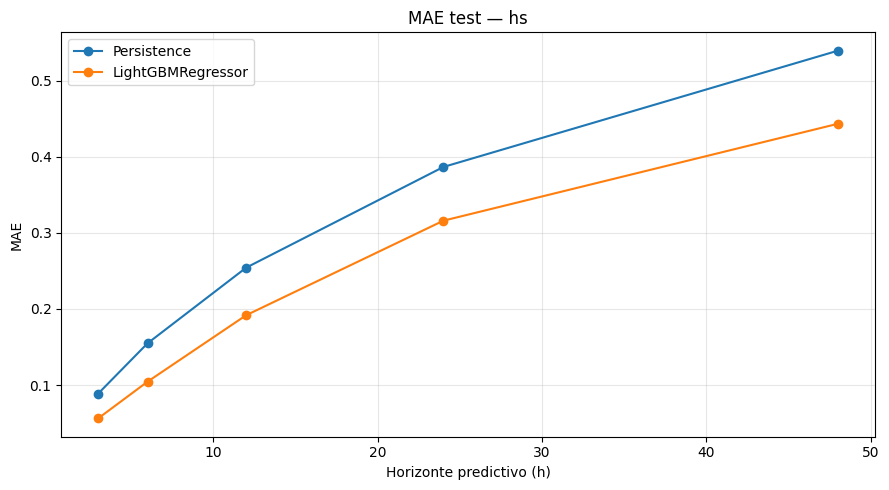

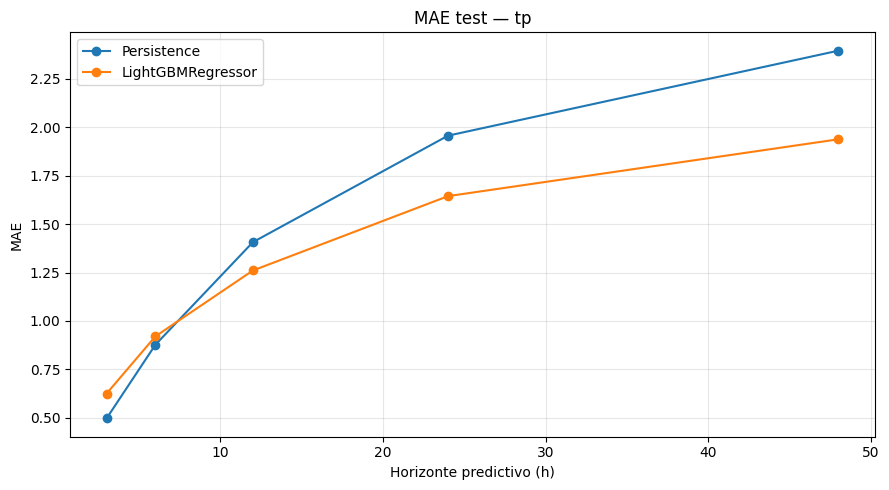

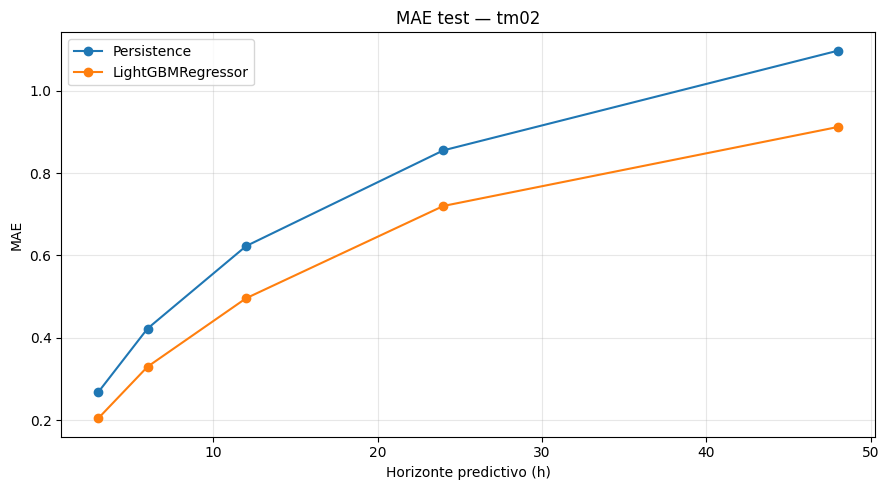

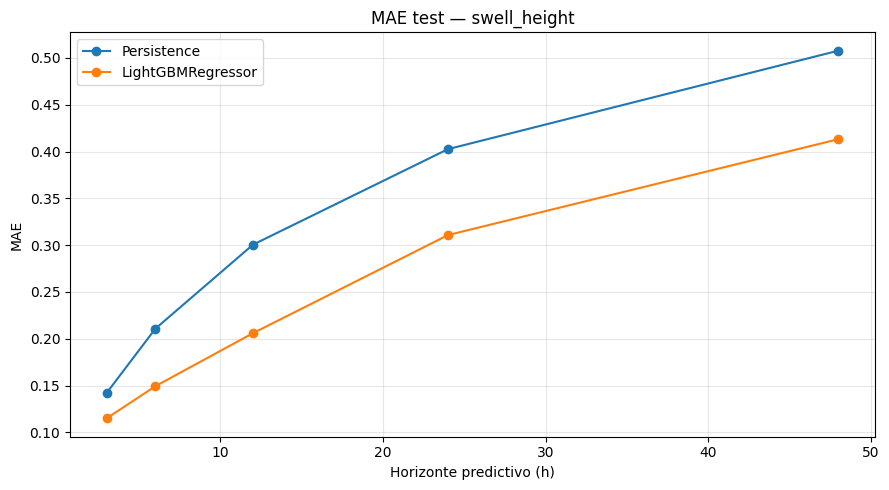

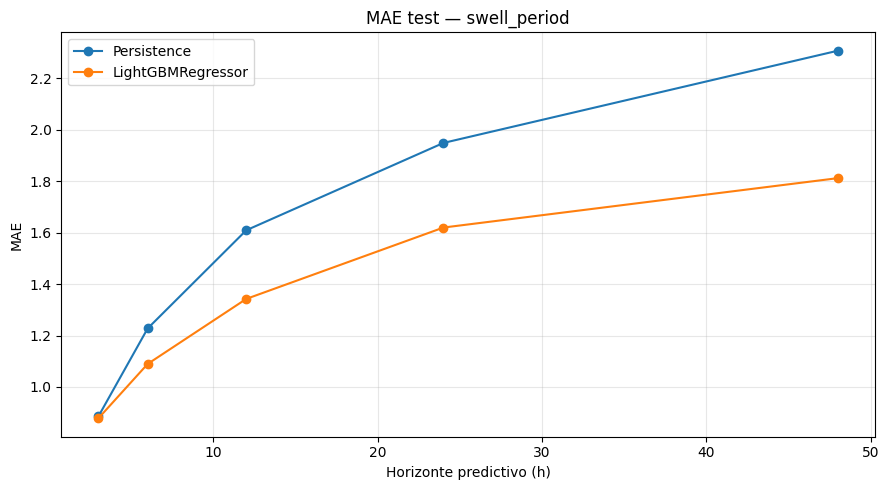

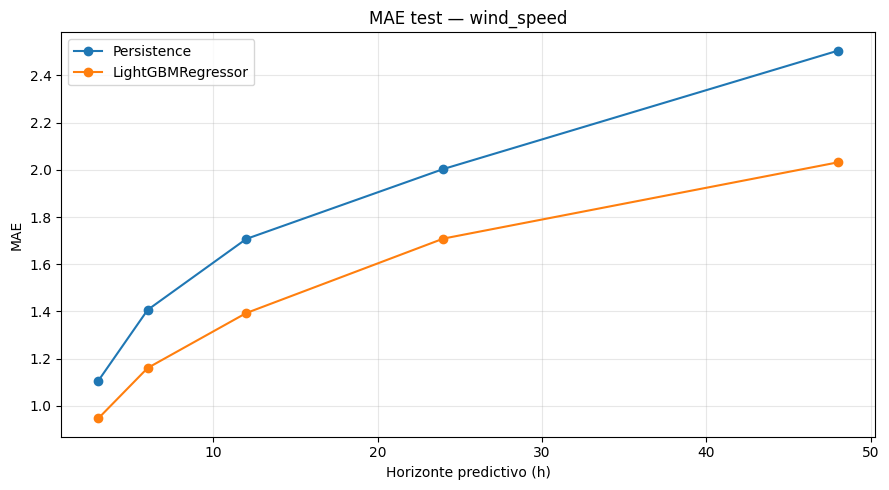

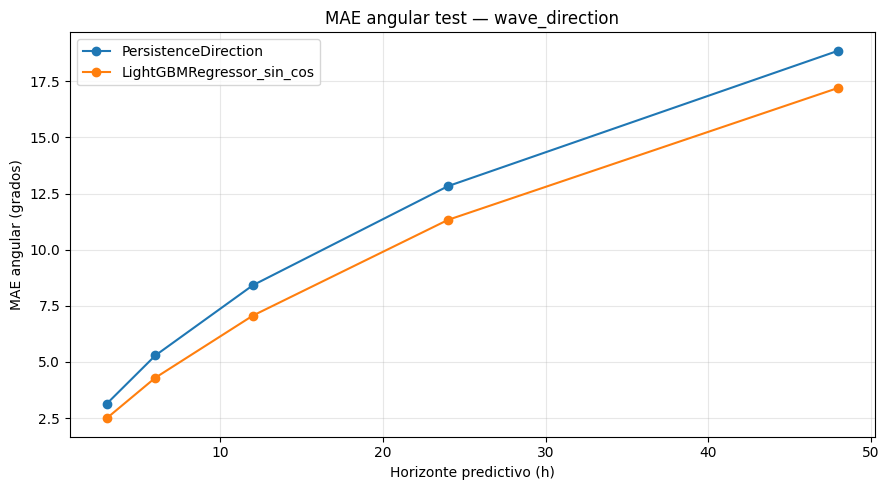

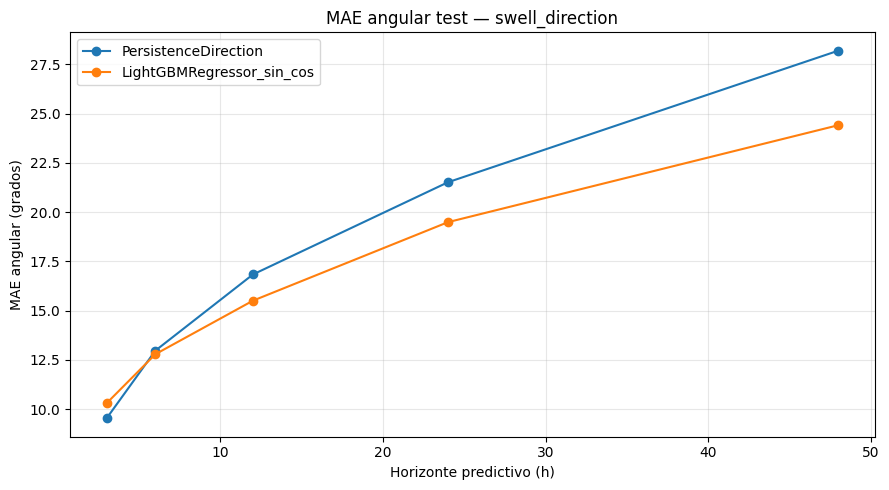

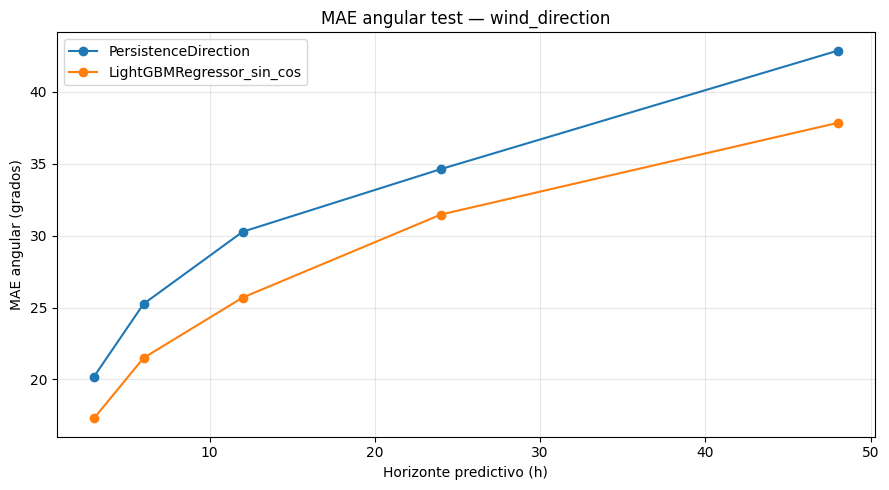

In [18]:
# Gráfico MAE de targets escalares principales.
if not scalar_test.empty:
    for target_name in [t for t in CORE_SCALAR_TARGETS if t in scalar_test["target_name"].unique()]:
        plt.figure(figsize=(9, 5))

        for model_name in ["Persistence", "LightGBMRegressor"]:
            data = scalar_test[
                (scalar_test["target_name"] == target_name)
                & (scalar_test["model"] == model_name)
            ].sort_values("horizon_hours")

            if data.empty:
                continue

            plt.plot(data["horizon_hours"], data["mae"], marker="o", label=model_name)

        plt.xlabel("Horizonte predictivo (h)")
        plt.ylabel("MAE")
        plt.title(f"MAE test — {target_name}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = RESULTS_DIR / f"plot_mae_{target_name}.png"
        plt.savefig(out, dpi=160)
        plt.show()

# Gráfico angular MAE de direcciones principales.
if not direction_test.empty:
    for target_name in [t for t in CORE_DIRECTION_TARGETS if t in direction_test["target_name"].unique()]:
        plt.figure(figsize=(9, 5))

        for model_name in ["PersistenceDirection", "LightGBMRegressor_sin_cos"]:
            data = direction_test[
                (direction_test["target_name"] == target_name)
                & (direction_test["model"] == model_name)
            ].sort_values("horizon_hours")

            if data.empty:
                continue

            plt.plot(data["horizon_hours"], data["angular_mae"], marker="o", label=model_name)

        plt.xlabel("Horizonte predictivo (h)")
        plt.ylabel("MAE angular (grados)")
        plt.title(f"MAE angular test — {target_name}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = RESULTS_DIR / f"plot_angular_mae_{target_name}.png"
        plt.savefig(out, dpi=160)
        plt.show()

## Celda 14 — Top features por target

,target_type,target_name,horizon_hours,component,feature,importance_gain
0,direction,current_direction,3,cos,simar_current_v,1.274588e+06
1,direction,current_direction,3,cos,simar_current_direction_cos,1.101541e+06
2,direction,current_direction,3,cos,simar_current_direction_sin,2.370835e+05
3,direction,current_direction,3,cos,simar_current_direction,1.617592e+05
4,direction,current_direction,3,cos,simar_current_speed,1.134268e+05
...,...,...,...,...,...,...
95,direction,current_direction,6,sin,simar_current_speed,8.280740e+04
96,direction,current_direction,6,sin,simar_current_speed_lag_6h,7.986087e+04
97,direction,current_direction,6,sin,redmar_sea_level_diff_1h_mt,7.096779e+04
98,direction,current_direction,6,sin,simar_current_speed_lag_3h,6.060855e+04


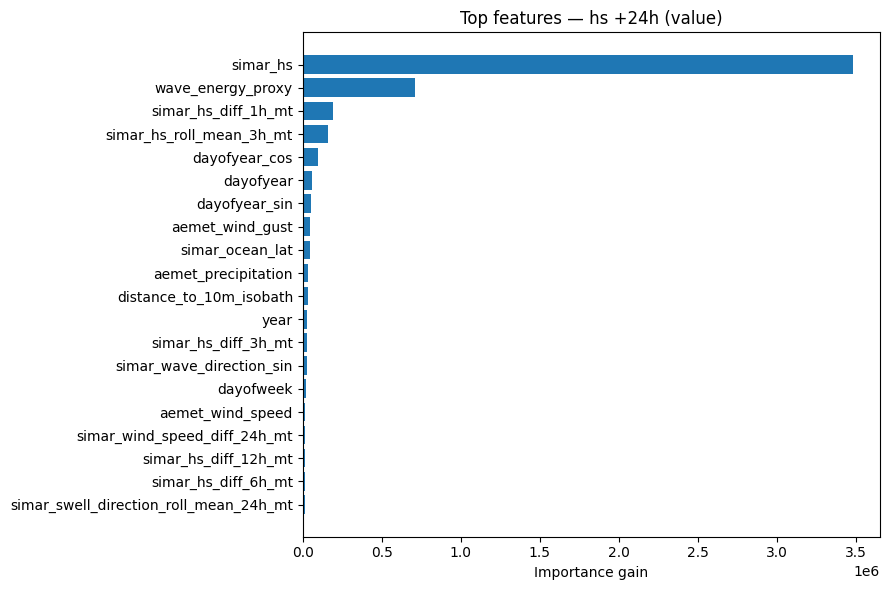

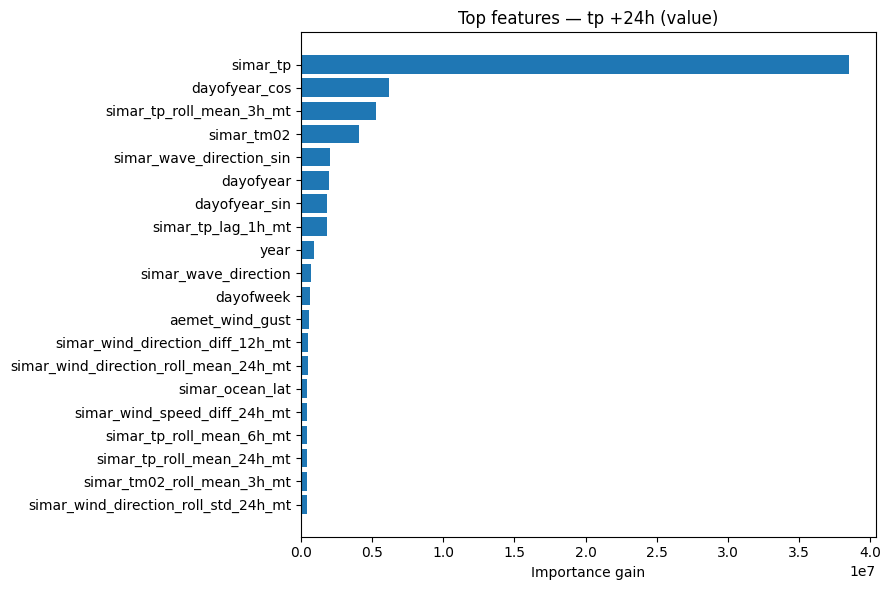

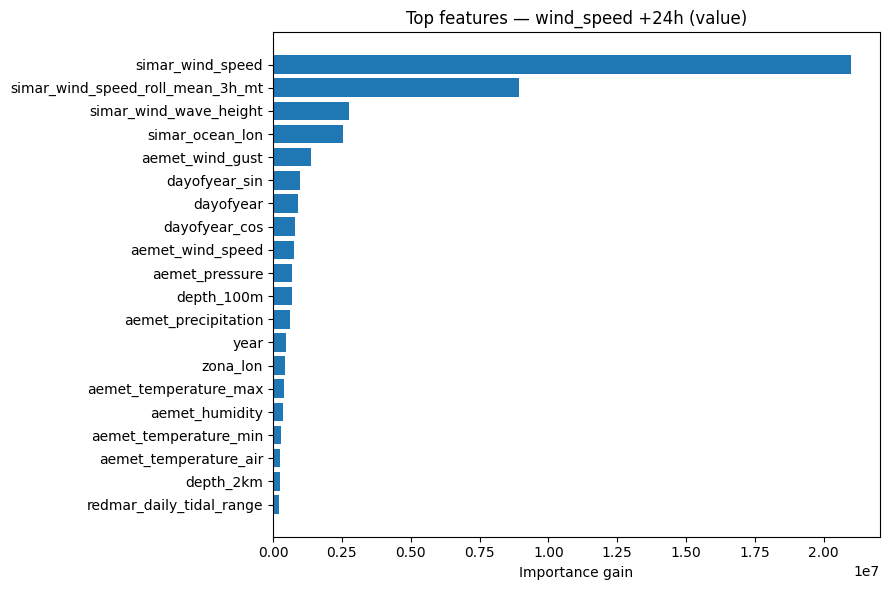

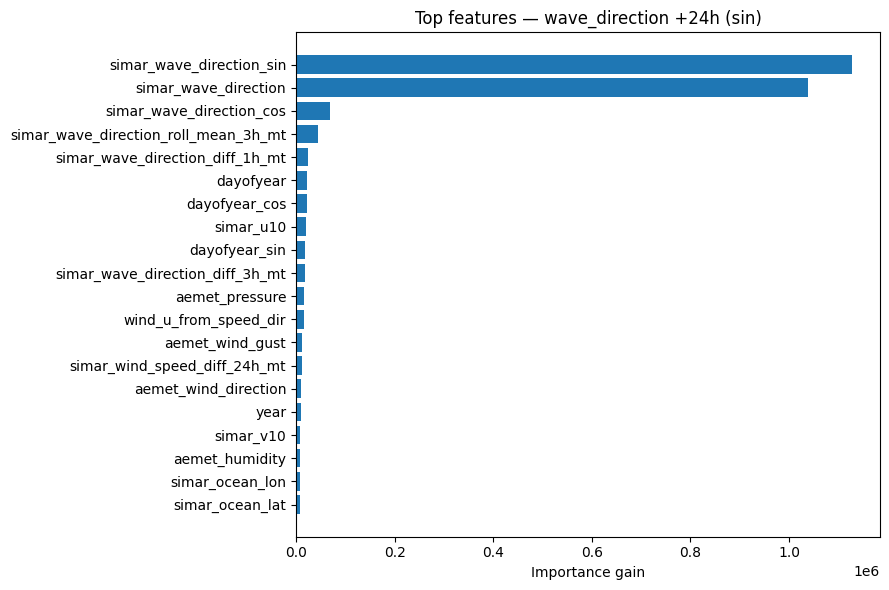

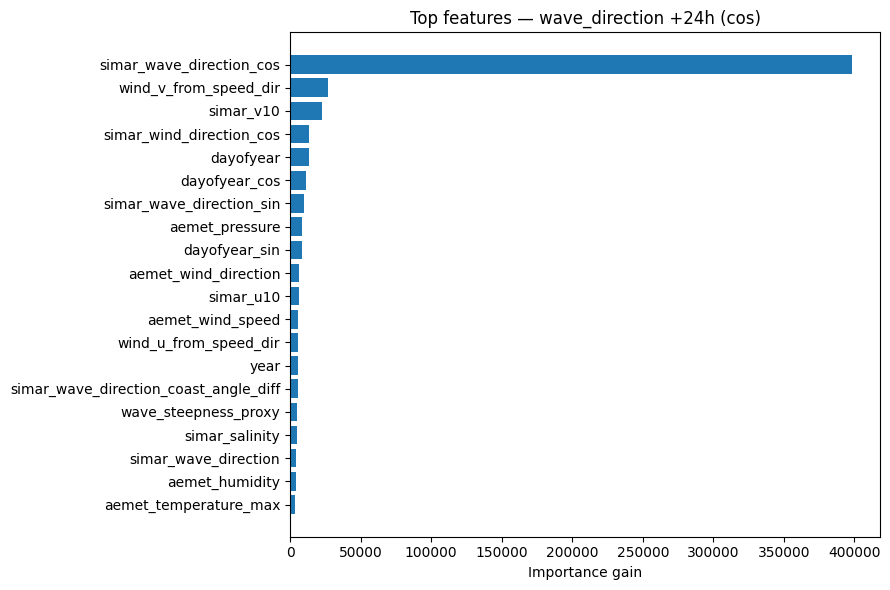

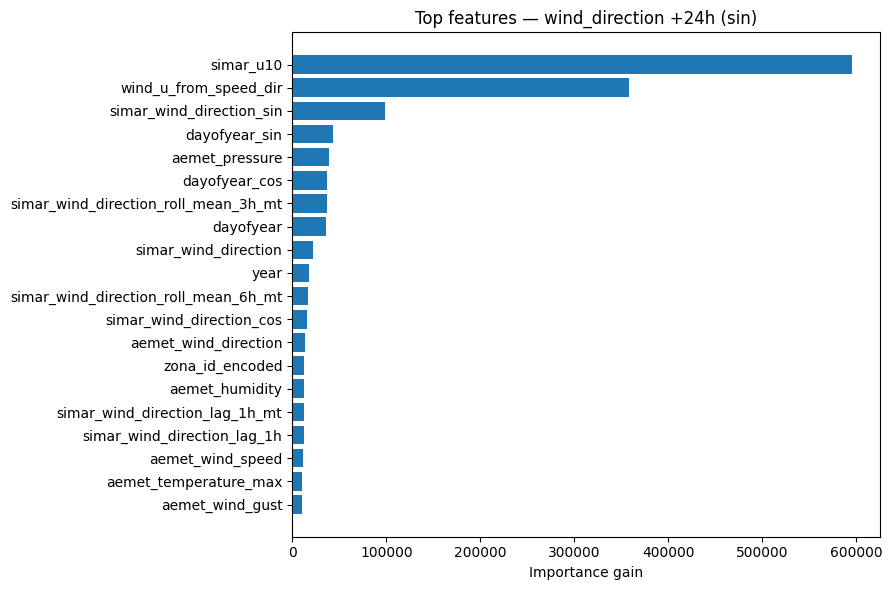

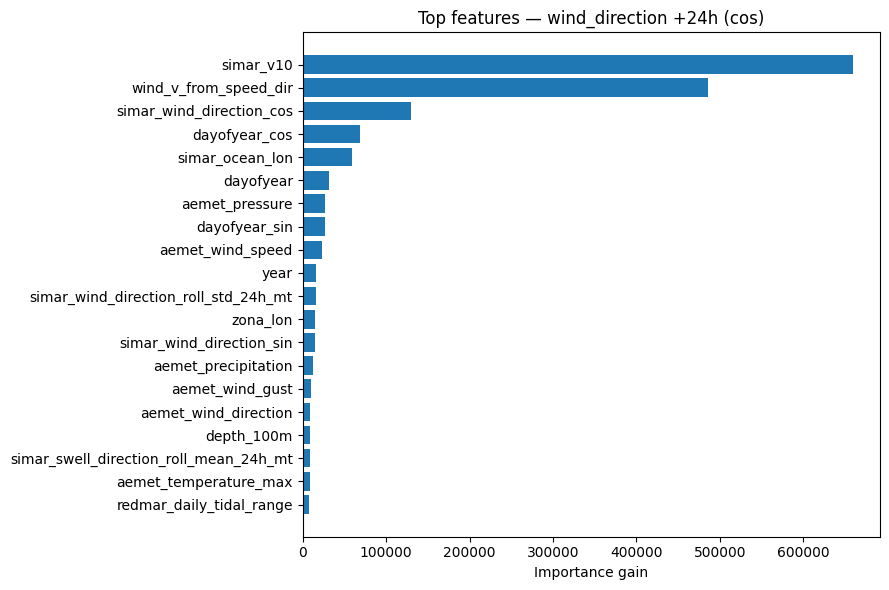

In [19]:
if not feature_importance_df.empty:
    top_features = (
        feature_importance_df
        .sort_values(["target_name", "horizon_hours", "component", "importance_gain"], ascending=[True, True, True, False])
        .groupby(["target_type", "target_name", "horizon_hours", "component"])
        .head(30)
        .reset_index(drop=True)
    )

    top_features.to_csv(RESULTS_DIR / "feature_importance_top30.csv", index=False)
    display(top_features.head(100))

    # Gráficos top 20 para targets clave a 24h.
    for target_name in ["hs", "tp", "wind_speed", "wave_direction", "wind_direction"]:
        for component in ["value", "sin", "cos"]:
            plot_df = top_features[
                (top_features["target_name"] == target_name)
                & (top_features["horizon_hours"] == 24)
                & (top_features["component"] == component)
            ].head(20)

            if plot_df.empty:
                continue

            plot_df = plot_df.sort_values("importance_gain", ascending=True)

            plt.figure(figsize=(9, 6))
            plt.barh(plot_df["feature"], plot_df["importance_gain"])
            plt.xlabel("Importance gain")
            plt.title(f"Top features — {target_name} +24h ({component})")
            plt.tight_layout()
            plt.savefig(RESULTS_DIR / f"plot_top_features_{target_name}_24h_{component}.png", dpi=160)
            plt.show()

## Celda 15 — Generar informe ejecutivo

In [20]:
report_lines = []
report_lines.append("# Resultados multitarget físico — DeepWave Canarias\n")
report_lines.append("## Dataset\n")
report_lines.append(f"- Entrada: `{INPUT_GOLD_DIR}`")
report_lines.append(f"- Filas: {len(gold):,}")
report_lines.append(f"- Columnas: {len(gold.columns):,}")
report_lines.append(f"- Features usadas: {len(encoded_feature_cols):,}")
report_lines.append(f"- Horizontes: {HORIZONS_HOURS}")
report_lines.append("\n## Modelos entrenados\n")
report_lines.append(f"- Modelos escalares LightGBM: {scalar_metrics_df[scalar_metrics_df['model'] == 'LightGBMRegressor'][['target_name', 'horizon_hours']].drop_duplicates().shape[0] if not scalar_metrics_df.empty else 0}")
report_lines.append(f"- Modelos direccionales sin/cos: {direction_metrics_df[direction_metrics_df['model'] == 'LightGBMRegressor_sin_cos'][['target_name', 'horizon_hours']].drop_duplicates().shape[0] if not direction_metrics_df.empty else 0}")
report_lines.append("\n## Targets escalares principales\n")

if "scalar_improvement_df" in globals() and not scalar_improvement_df.empty:
    for target_name in CORE_SCALAR_TARGETS:
        sub = scalar_improvement_df[scalar_improvement_df["target_name"] == target_name].sort_values("horizon_hours")
        if sub.empty:
            continue

        report_lines.append(f"\n### {target_name}\n")
        for _, row in sub.iterrows():
            report_lines.append(
                f"- +{int(row['horizon_hours'])}h: MAE={row['mae_model']:.4f}, "
                f"persistencia={row['mae_persistence']:.4f}, "
                f"mejora={row['mae_improvement_pct']:.2f}%"
            )

report_lines.append("\n## Targets direccionales principales\n")

if "direction_improvement_df" in globals() and not direction_improvement_df.empty:
    for target_name in CORE_DIRECTION_TARGETS:
        sub = direction_improvement_df[direction_improvement_df["target_name"] == target_name].sort_values("horizon_hours")
        if sub.empty:
            continue

        report_lines.append(f"\n### {target_name}\n")
        for _, row in sub.iterrows():
            report_lines.append(
                f"- +{int(row['horizon_hours'])}h: MAE angular={row['angular_mae_model']:.2f}°, "
                f"persistencia={row['angular_mae_persistence']:.2f}°, "
                f"mejora={row['angular_mae_improvement_pct']:.2f}%"
            )

report_md = "\n".join(report_lines)

(RESULTS_DIR / "multitarget_physical_report.md").write_text(report_md, encoding="utf-8")

summary_json = {
    "dataset": str(INPUT_GOLD_DIR),
    "results_dir": str(RESULTS_DIR),
    "models_dir": str(MODELS_DIR),
    "rows": int(len(gold)),
    "columns": int(len(gold.columns)),
    "feature_count": int(len(encoded_feature_cols)),
    "horizons_hours": HORIZONS_HOURS,
    "scalar_targets": SCALAR_TARGETS,
    "direction_targets": DIRECTION_TARGETS,
    "train_optional_targets": TRAIN_OPTIONAL_TARGETS,
    "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
    "n_jobs": N_JOBS,
    "n_estimators": N_ESTIMATORS,
    "learning_rate": LEARNING_RATE,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "scalar_models_trained": int(scalar_metrics_df[scalar_metrics_df["model"] == "LightGBMRegressor"][["target_name", "horizon_hours"]].drop_duplicates().shape[0]) if not scalar_metrics_df.empty else 0,
    "direction_models_trained": int(direction_metrics_df[direction_metrics_df["model"] == "LightGBMRegressor_sin_cos"][["target_name", "horizon_hours"]].drop_duplicates().shape[0]) if not direction_metrics_df.empty else 0,
}

save_json(summary_json, RESULTS_DIR / "multitarget_physical_summary.json")
save_json(summary_json, MODELS_DIR / "multitarget_physical_summary.json")

print(report_md[:3000])
print("\nInforme guardado:", RESULTS_DIR / "multitarget_physical_report.md")

# Resultados multitarget físico — DeepWave Canarias

## Dataset

- Entrada: `/Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/multitarget_training_dataset`
- Filas: 983,328
- Columnas: 673
- Features usadas: 318
- Horizontes: [3, 6, 12, 24, 48]

## Modelos entrenados

- Modelos escalares LightGBM: 60
- Modelos direccionales sin/cos: 20

## Targets escalares principales


### hs

- +3h: MAE=0.0562, persistencia=0.0888, mejora=36.70%
- +6h: MAE=0.1044, persistencia=0.1548, mejora=32.55%
- +12h: MAE=0.1917, persistencia=0.2542, mejora=24.58%
- +24h: MAE=0.3159, persistencia=0.3865, mejora=18.26%
- +48h: MAE=0.4432, persistencia=0.5392, mejora=17.81%

### tp

- +3h: MAE=0.6255, persistencia=0.4976, mejora=-25.70%
- +6h: MAE=0.9205, persistencia=0.8772, mejora=-4.93%
- +12h: MAE=1.2605, persistencia=1.4067, mejora=10.40%
- +24h: MAE=1.6441, persistencia=1.9561, mejora=15.95%
- +48h: MAE=1.9373, persistencia=2.3944, mejora=19.09%

### tm02

- +3h: MAE=0.2043, persi

## Celda 16 — Validación final

In [21]:
required_files = [
    RESULTS_DIR / "target_inventory.csv",
    RESULTS_DIR / "feature_selection_audit.csv",
    RESULTS_DIR / "feature_metadata.json",
    RESULTS_DIR / "metrics_scalar_regression.csv",
    RESULTS_DIR / "metrics_direction_regression.csv",
    RESULTS_DIR / "training_summary.csv",
    RESULTS_DIR / "feature_importance.csv",
    RESULTS_DIR / "multitarget_physical_report.md",
    RESULTS_DIR / "multitarget_physical_summary.json",
    MODELS_DIR / "feature_metadata.json",
    MODELS_DIR / "multitarget_physical_summary.json",
]

missing = [str(p) for p in required_files if not p.exists()]

if missing:
    raise FileNotFoundError("Faltan archivos requeridos: " + json.dumps(missing, indent=2))

if training_summary_df.empty:
    raise ValueError("No se entrenó ningún modelo.")

if not scalar_metrics_df.empty:
    scalar_test_lgbm = scalar_metrics_df[
        (scalar_metrics_df["split"] == "test")
        & (scalar_metrics_df["model"] == "LightGBMRegressor")
    ]
    if scalar_test_lgbm["mae"].isna().any():
        raise ValueError("Hay MAE nulos en métricas escalares test.")

if not direction_metrics_df.empty:
    direction_test_lgbm = direction_metrics_df[
        (direction_metrics_df["split"] == "test")
        & (direction_metrics_df["model"] == "LightGBMRegressor_sin_cos")
    ]
    if direction_test_lgbm["angular_mae"].isna().any():
        raise ValueError("Hay angular_mae nulos en métricas direccionales test.")

print("Modelos entrenados:")
display(training_summary_df)

print("\nArchivos principales:")
for p in required_files:
    print("-", p)

print("\nModelos guardados:")
model_files = list(MODELS_DIR.rglob("*.pkl"))
print("Total .pkl:", len(model_files))
for p in model_files[:30]:
    print("-", p)
if len(model_files) > 30:
    print("...")

print("\n✅ Entrenamiento físico multitarget completado correctamente.")

Modelos entrenados:


,target_type,target_name,horizon_hours,target_col,source_col_for_baseline,train_rows,val_rows,test_rows,best_iteration,model_path,best_iteration_sin,best_iteration_cos,model_sin_path,model_cos_path
0,scalar,hs,3,target_hs_3h,simar_hs,698181,87300,197043,2774.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
1,scalar,hs,6,target_hs_6h,simar_hs,697650,87240,196830,1711.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
2,scalar,hs,12,target_hs_12h,simar_hs,696588,87120,196404,1053.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
3,scalar,hs,24,target_hs_24h,simar_hs,694464,86880,195552,237.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
4,scalar,hs,48,target_hs_48h,simar_hs,690456,86400,193848,139.0,/Users/rauljimenez/Development/Projects/AI-Pro...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,direction,current_direction,3,target_current_direction_3h,simar_current_direction,612706,85524,189852,NaN,NaN,2833.0,3498.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
76,direction,current_direction,6,target_current_direction_6h,simar_current_direction,612214,85464,189648,NaN,NaN,1481.0,838.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
77,direction,current_direction,12,target_current_direction_12h,simar_current_direction,611231,85344,189240,NaN,NaN,2000.0,1696.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
78,direction,current_direction,24,target_current_direction_24h,simar_current_direction,609275,85104,188424,NaN,NaN,512.0,367.0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...



Archivos principales:
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/target_inventory.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/feature_selection_audit.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/feature_metadata.json
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/metrics_scalar_regression.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/metrics_direction_regression.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/training_summary.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/feature_importance.csv
- /Users

## Resultado esperado

Al final debe aparecer:

```text
✅ Entrenamiento físico multitarget completado correctamente.
```

Salidas principales:

```text
models/multitarget_physical/
gold/model_results/multitarget_physical/
```

Archivos clave:

```text
metrics_scalar_regression.csv
metrics_direction_regression.csv
test_improvement_scalar_vs_persistence.csv
test_improvement_direction_vs_persistence.csv
training_summary.csv
feature_importance.csv
feature_importance_top30.csv
multitarget_physical_report.md
multitarget_physical_summary.json
```

Después de ejecutarlo, pásame los resultados para decidir:

```text
- qué variables físicas quedan bien predichas
- cuáles no merecen modelo propio
- si el siguiente paso será 16_model_training_risk_modules.ipynb
```